# Robustness of Multimodal Wearable HAR under Realistic Sensor-Failure Processes
**Phase 0 - Setup & Raw Dropout Statistics**

Goal of this phase: download PAMAP2 and OPPORTUNITY in their *raw* form and
characterize the real, naturally occurring data loss (NaN runs from wireless
dropouts) before any cleaning. These statistics will calibrate the failure-process
simulator (C1) and become Figure 1 of the paper.

This cell defines all constants and creates the project folder structure.

# Cell 0 - Bootstrap: download datasets and build the folder tree

In [1]:
# ================= BOOTSTRAP - run once at every session start =============
import os, re, glob, json, random, zipfile, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats as st

SEED = 42
random.seed(SEED); np.random.seed(SEED)

BASE = "/kaggle/working"
DIRS = {n: os.path.join(BASE, n) for n in
        ["fig", "dataset", "output", "model", "hls", "_state"]}
for d in DIRS.values():
    os.makedirs(d, exist_ok=True)

FIG_DPI, PANEL_LABEL_Y = 300, -0.18
FS_PAMAP2, FS_OPP, FS_MH = 100, 30, 50
FS = {"pamap2": 100, "opportunity": 30, "mhealth": 50}

URLS = {
    "pamap2":      "https://archive.ics.uci.edu/static/public/231/pamap2+physical+activity+monitoring.zip",
    "opportunity": "https://archive.ics.uci.edu/static/public/226/opportunity+activity+recognition.zip",
    "mhealth":     "https://archive.ics.uci.edu/static/public/319/mhealth+dataset.zip",
}

import socket, time as _time

def fetch(name, url, timeout=60, retries=4):
    zpath = os.path.join(DIRS["dataset"], f"{name}.zip")
    out = os.path.join(DIRS["dataset"], name)
    if os.path.exists(out):
        return out
    last = None
    for attempt in range(1, retries + 1):
        try:
            print(f"Downloading {name} (attempt {attempt}) ...")
            socket.setdefaulttimeout(timeout)
            urllib.request.urlretrieve(url, zpath)
            break
        except Exception as e:
            last = e
            print(f"  failed: {e}; retrying in 30 s")
            if os.path.exists(zpath):
                os.remove(zpath)
            _time.sleep(30)
    else:
        raise RuntimeError(f"{name} download failed after {retries} tries: {last}")
    with zipfile.ZipFile(zpath) as z:
        z.extractall(out)
    os.remove(zpath)
    for root, _, files in os.walk(out):
        for f in files:
            if f.endswith(".zip"):
                inner = os.path.join(root, f)
                with zipfile.ZipFile(inner) as z:
                    z.extractall(root)
                os.remove(inner)
    print(f"{name}: done")
    return out

for name, url in URLS.items():
    fetch(name, url)

# ---------------- shared helpers -------------------------------------------
def run_lengths(mask):
    if not mask.any():
        return np.array([], dtype=int)
    m = np.concatenate(([0], mask.view(np.int8), [0]))
    d = np.diff(m)
    return np.where(d == -1)[0] - np.where(d == 1)[0]

def runs_with_position(mask):
    if not mask.any():
        return []
    m = np.concatenate(([0], mask.view(np.int8), [0]))
    d = np.diff(m)
    starts, ends = np.where(d == 1)[0], np.where(d == -1)[0]
    return [(int(e - s), s == 0 or e == len(mask))
            for s, e in zip(starts, ends)]

def gap_lengths(mask):
    if not mask.any():
        return np.array([], dtype=int)
    m = np.concatenate(([0], mask.view(np.int8), [0]))
    d = np.diff(m)
    starts, ends = np.where(d == 1)[0], np.where(d == -1)[0]
    return starts[1:] - ends[:-1]

# ---------------- dataset structure constants ------------------------------
IMU_BLOCKS = {"hand": list(range(3, 20)),
              "chest": list(range(20, 37)),
              "ankle": list(range(37, 54))}
BODY_ACC = {"BACK", "HIP", "LH", "RH", "LUA^", "LUA_", "LWR",
            "RKN^", "RKN_", "RUA^", "RUA_", "RWR"}
CATASTROPHIC = {("S2-ADL5", "Accelerometer RH"),
                ("S1-Drill", "Accelerometer RWR"),
                ("S4-ADL3", "Accelerometer LH")}

proto = sorted(glob.glob(os.path.join(
    DIRS["dataset"], "pamap2", "**", "Protocol", "*.dat"), recursive=True))
dats = sorted(glob.glob(os.path.join(
    DIRS["dataset"], "opportunity", "**", "S[1-4]-*.dat"), recursive=True))

cn_path = glob.glob(os.path.join(DIRS["dataset"], "opportunity", "**",
                                 "column_names.txt"), recursive=True)[0]
device_cols = {}
with open(cn_path) as f:
    for line in f:
        m = re.match(r"Column:\s+(\d+)\s+(.*)", line.strip())
        if not m:
            continue
        idx = int(m.group(1)) - 1
        desc = m.group(2).split(";")[0].strip()
        parts = desc.split()
        if len(parts) < 2 or parts[0] in ("MILLISEC",) or "Label" in desc:
            continue
        device_cols.setdefault(" ".join(parts[:-1]), []).append(idx)
body = {}
for d_, c in device_cols.items():
    kind, loc = d_.split()[0], d_.split()[-1]
    if (kind == "Accelerometer" and loc in BODY_ACC) or \
       kind == "InertialMeasurementUnit":
        body[d_] = c

# ---------------- artifact inventory ---------------------------------------
NEEDED = ["pamap2_run_lengths.csv", "pamap2_gaps.csv", "pamap2_dropout_stats.csv",
          "opportunity_run_lengths.csv", "opportunity_gaps.csv",
          "opportunity_dropout_stats.csv", "burst_fit_params.csv",
          "gap_fit_params.csv"]
missing = [f for f in NEEDED if not os.path.exists(
    os.path.join(DIRS["output"], f))]
print(f"pamap2 files: {len(proto)} | opportunity sessions: {len(dats)} | "
      f"body devices: {len(body)}")
print("missing output artifacts:", missing if missing else "NONE - all present")
print("failure_sim.py:",
      "present" if os.path.exists(os.path.join(DIRS['model'],
                                               'failure_sim.py')) else "MISSING")

# load pools into memory if CSVs exist (used by later cells)
if not missing:
    p_runs = pd.read_csv(os.path.join(DIRS["output"], "pamap2_run_lengths.csv"))
    o_runs = pd.read_csv(os.path.join(DIRS["output"],
                                      "opportunity_run_lengths.csv"))
    o_b = o_runs[(o_runs["kind"] == "Accelerometer") & (~o_runs["boundary"])]
    o_b = o_b[~o_b.apply(lambda r: (r["session"], r["device"])
                         in CATASTROPHIC, axis=1)]
    burst_sets = {"pamap2": p_runs["run_samples"].to_numpy(),
                  "opportunity": o_b["run_samples"].to_numpy()}
    gap_sets = {"pamap2": pd.read_csv(os.path.join(
                    DIRS["output"], "pamap2_gaps.csv"))["gap_samples"].to_numpy(),
                "opportunity": pd.read_csv(os.path.join(
                    DIRS["output"], "opportunity_gaps.csv"))["gap_samples"].to_numpy()}
    print("pools loaded:", {k: len(v) for k, v in burst_sets.items()})

pamap2: done
opportunity: done
mhealth: done
pamap2 files: 9 | opportunity sessions: 24 | body devices: 19
missing output artifacts: ['pamap2_run_lengths.csv', 'pamap2_gaps.csv', 'pamap2_dropout_stats.csv', 'opportunity_run_lengths.csv', 'opportunity_gaps.csv', 'opportunity_dropout_stats.csv', 'burst_fit_params.csv', 'gap_fit_params.csv']
failure_sim.py: MISSING


# Cell 0b - Restore artifacts from an attached previous version

In [2]:
# ---- Cell 0b: restore artifacts from attached previous version -------------
import shutil

def find_input_root():
    """Locate the attached notebook-output containing our output/ dir."""
    hits = glob.glob("/kaggle/input/**/output/splits.json", recursive=True)
    return os.path.dirname(os.path.dirname(hits[0])) if hits else None

src = find_input_root()
if src is None:
    print("no previous-version input found - full recompute will run")
else:
    print(f"restoring from: {src}")
    for sub in ("output", "model", "fig", os.path.join("dataset", "proc")):
        s, d = os.path.join(src, sub), os.path.join(BASE, sub)
        if not os.path.exists(s):
            print(f"  [absent in input] {sub}")
            continue
        os.makedirs(d, exist_ok=True)
        n = 0
        for root, _, files in os.walk(s):
            rel = os.path.relpath(root, s)
            os.makedirs(os.path.join(d, rel), exist_ok=True)
            for f in files:
                dst = os.path.join(d, rel, f)
                if not os.path.exists(dst):
                    shutil.copy2(os.path.join(root, f), dst)
                    n += 1
        print(f"  {sub}: {n} files restored")

# reload pools now that CSVs are in place (mirrors bootstrap's tail)
if os.path.exists(os.path.join(DIRS["output"], "pamap2_run_lengths.csv")):
    p_runs = pd.read_csv(os.path.join(DIRS["output"], "pamap2_run_lengths.csv"))
    o_runs = pd.read_csv(os.path.join(DIRS["output"],
                                      "opportunity_run_lengths.csv"))
    o_b = o_runs[(o_runs["kind"] == "Accelerometer") & (~o_runs["boundary"])]
    o_b = o_b[~o_b.apply(lambda r: (r["session"], r["device"])
                         in CATASTROPHIC, axis=1)]
    burst_sets = {"pamap2": p_runs["run_samples"].to_numpy(),
                  "opportunity": o_b["run_samples"].to_numpy()}
    gap_sets = {"pamap2": pd.read_csv(os.path.join(
                    DIRS["output"], "pamap2_gaps.csv"))["gap_samples"].to_numpy(),
                "opportunity": pd.read_csv(os.path.join(
                    DIRS["output"], "opportunity_gaps.csv"))["gap_samples"].to_numpy()}
    print("pools loaded:", {k: len(v) for k, v in burst_sets.items()})
print("ckpt files:", len(glob.glob(os.path.join(DIRS["model"],
                                                "ckpt", "*.pt"))))

restoring from: /kaggle/input/notebooks/kmdr82/notebook201b18a32a
  output: 29 files restored
  model: 616 files restored
  fig: 11 files restored
  dataset/proc: 23 files restored
pools loaded: {'pamap2': 18557, 'opportunity': 4787}
ckpt files: 340


## Download raw datasets

Both archives are fetched from the UCI repository (internet must be enabled in
Kaggle notebook settings). We keep the **raw** files: PAMAP2 `.dat` files contain
genuine NaN entries from wireless data loss, and OPPORTUNITY column streams
contain missing values from Bluetooth dropouts - exactly the signal we want to
measure, so no interpolation is applied at this stage.

## PAMAP2 - raw dropout statistics

PAMAP2 `.dat` files are space-separated with 54 columns: timestamp (s),
activityID, heart rate, then 3 IMUs (hand, chest, ankle) x 17 columns each,
sampled at 100 Hz. Heart-rate NaNs are *structural* (HR is sampled at ~9 Hz),
so they are excluded from dropout analysis. IMU NaNs are genuine wireless
data-loss events: a dropped packet blanks all columns of that IMU
simultaneously.

For each subject x IMU we compute: missing fraction, number of missing runs,
and the run-length distribution (in samples and seconds). We verify the
"packet-level" assumption by comparing any-NaN vs all-NaN per IMU block.
Outputs: `output/pamap2_dropout_stats.csv` (per subject x sensor summary) and
`output/pamap2_run_lengths.csv` (one row per missing run - Figure 1 raw data).

In [3]:
import glob
import pandas as pd

FS_PAMAP2 = 100  # Hz

# column layout: 0=time, 1=activity, 2=HR, then 17-col blocks per IMU
IMU_BLOCKS = {
    "hand":  list(range(3, 20)),
    "chest": list(range(20, 37)),
    "ankle": list(range(37, 54)),
}

def run_lengths(mask):
    """Lengths (in samples) of consecutive True runs in a boolean array."""
    if not mask.any():
        return np.array([], dtype=int)
    m = np.concatenate(([0], mask.view(np.int8), [0]))
    d = np.diff(m)
    starts, ends = np.where(d == 1)[0], np.where(d == -1)[0]
    return ends - starts

proto = sorted(glob.glob(os.path.join(
    DIRS["dataset"], "pamap2", "**", "Protocol", "*.dat"), recursive=True))
print(f"{len(proto)} protocol files found")

summary, runs_rows = [], []
for path in proto:
    subj = os.path.basename(path).replace(".dat", "")
    df = pd.read_csv(path, sep=r"\s+", header=None)
    n = len(df)
    for imu, cols in IMU_BLOCKS.items():
        block = df[cols].to_numpy()
        any_nan = np.isnan(block).any(axis=1)
        all_nan = np.isnan(block).all(axis=1)
        rl = run_lengths(any_nan)
        summary.append({
            "subject": subj, "imu": imu, "n_samples": n,
            "missing_frac": any_nan.mean(),
            "n_runs": len(rl),
            "packet_level_agreement": float(
                (any_nan == all_nan).mean()),  # ~1.0 => whole-IMU dropouts
            "median_run_s": np.median(rl) / FS_PAMAP2 if len(rl) else 0.0,
            "p95_run_s": np.percentile(rl, 95) / FS_PAMAP2 if len(rl) else 0.0,
            "max_run_s": rl.max() / FS_PAMAP2 if len(rl) else 0.0,
        })
        runs_rows += [{"subject": subj, "imu": imu,
                       "run_samples": int(r),
                       "run_s": r / FS_PAMAP2} for r in rl]

stats = pd.DataFrame(summary)
runs  = pd.DataFrame(runs_rows)
stats.to_csv(os.path.join(DIRS["output"], "pamap2_dropout_stats.csv"), index=False)
runs.to_csv(os.path.join(DIRS["output"], "pamap2_run_lengths.csv"), index=False)

print(stats.groupby("imu")[["missing_frac", "median_run_s",
                            "p95_run_s", "max_run_s"]].mean().round(4))
print(f"\ntotal missing runs across subjects: {len(runs)}")
print("packet-level agreement (min over files):",
      round(stats["packet_level_agreement"].min(), 4))

9 protocol files found
       missing_frac  median_run_s  p95_run_s  max_run_s
imu                                                    
ankle        0.0036        0.0111     0.0351     0.3156
chest        0.0017        0.0100     0.0430     0.2278
hand         0.0040        0.0106     0.0322     0.2878

total missing runs across subjects: 18557
packet-level agreement (min over files): 1.0


## OPPORTUNITY - raw dropout statistics

OPPORTUNITY (30 Hz) records 4 subjects x 6 sessions (5 ADL + 1 Drill) with
body-worn wireless accelerometers, 7 IMUs (including two shoe IMUs), plus
object/ambient sensors. Wireless (Bluetooth) dropouts appear as NaN entries
in the raw `.dat` files.

Instead of hardcoding the 250-column layout, we parse the dataset's own
`column_names.txt` and group channels by device (e.g. "Accelerometer RKN^",
"InertialMeasurementUnit BACK"). We restrict the dropout analysis to
body-worn devices (accelerometers + IMUs) - the wearable setting of the
paper - and compute the same statistics as for PAMAP2: missing fraction,
run counts, run-length distributions, and per-device NaN co-occurrence.

Outputs: `output/opportunity_dropout_stats.csv`,
`output/opportunity_run_lengths.csv`.

In [4]:
import re

FS_OPP = 30  # Hz
opp_root = os.path.join(DIRS["dataset"], "opportunity")

cn_path = glob.glob(os.path.join(opp_root, "**", "column_names.txt"),
                    recursive=True)[0]
device_cols = {}
with open(cn_path) as f:
    for line in f:
        m = re.match(r"Column:\s+(\d+)\s+(.*)", line.strip())
        if not m:
            continue
        idx = int(m.group(1)) - 1
        desc = m.group(2).split(";")[0].strip()
        parts = desc.split()
        if len(parts) < 2 or parts[0] in ("MILLISEC",) or "Label" in desc:
            continue
        device = " ".join(parts[:-1])
        device_cols.setdefault(device, []).append(idx)

# explicit whitelist: 12 wireless body accelerometers + 7 (wired) IMUs
BODY_ACC = {"BACK", "HIP", "LH", "RH", "LUA^", "LUA_", "LWR",
            "RKN^", "RKN_", "RUA^", "RUA_", "RWR"}
body = {}
for d, c in device_cols.items():
    kind, loc = d.split()[0], d.split()[-1]
    if kind == "Accelerometer" and loc in BODY_ACC:
        body[d] = c
    elif kind == "InertialMeasurementUnit":
        body[d] = c
print(f"{len(body)} body-worn devices kept "
      f"({sum(d.startswith('Acc') for d in body)} wireless acc, "
      f"{sum(d.startswith('Iner') for d in body)} IMU)")

def runs_with_position(mask):
    """(length, is_boundary) for each True-run; boundary = touches start/end."""
    if not mask.any():
        return []
    m = np.concatenate(([0], mask.view(np.int8), [0]))
    d = np.diff(m)
    starts, ends = np.where(d == 1)[0], np.where(d == -1)[0]
    return [(int(e - s), s == 0 or e == len(mask))
            for s, e in zip(starts, ends)]

dats = sorted(glob.glob(os.path.join(opp_root, "**", "S[1-4]-*.dat"),
                        recursive=True))
summary, runs_rows = [], []
for path in dats:
    sess = os.path.basename(path).replace(".dat", "")
    subj = sess.split("-")[0]
    df = pd.read_csv(path, sep=r"\s+", header=None)
    n = len(df)
    for dev, cols in body.items():
        block = df[cols].to_numpy()
        any_nan = np.isnan(block).any(axis=1)
        all_nan = np.isnan(block).all(axis=1)
        rr = runs_with_position(any_nan)
        interior = [L for L, b in rr if not b]
        summary.append({
            "subject": subj, "session": sess, "device": dev,
            "kind": dev.split()[0], "n_samples": n,
            "missing_frac": any_nan.mean(),
            "interior_missing_frac": sum(interior) / n,
            "n_runs": len(rr), "n_interior_runs": len(interior),
            "packet_level_agreement": float((any_nan == all_nan).mean()),
            "median_run_s": (np.median(interior) / FS_OPP
                             if interior else 0.0),
            "p95_run_s": (np.percentile(interior, 95) / FS_OPP
                          if interior else 0.0),
            "max_run_s": max(interior) / FS_OPP if interior else 0.0,
        })
        runs_rows += [{"subject": subj, "session": sess, "device": dev,
                       "kind": dev.split()[0], "run_samples": L,
                       "run_s": L / FS_OPP, "boundary": b}
                      for L, b in rr]

stats_o = pd.DataFrame(summary)
runs_o  = pd.DataFrame(runs_rows)
stats_o.to_csv(os.path.join(DIRS["output"],
               "opportunity_dropout_stats.csv"), index=False)
runs_o.to_csv(os.path.join(DIRS["output"],
              "opportunity_run_lengths.csv"), index=False)

print("\nINTERIOR runs only (boundary/sync blocks excluded):")
print(stats_o.groupby("kind")[["interior_missing_frac", "median_run_s",
                               "p95_run_s", "max_run_s"]].mean().round(4))
print(f"\ninterior runs: {int(stats_o['n_interior_runs'].sum())} | "
      f"boundary runs: {int((~runs_o['boundary']).size - runs_o['boundary'].size + 2*runs_o['boundary'].sum()) if False else int(runs_o['boundary'].sum())}")
print("packet-level agreement (min):",
      round(stats_o["packet_level_agreement"].min(), 4))
print("\nworst 5 (interior) device x session:")
print(stats_o.nlargest(5, "interior_missing_frac")[
    ["session", "device", "interior_missing_frac",
     "max_run_s"]].to_string(index=False))

19 body-worn devices kept (12 wireless acc, 7 IMU)

INTERIOR runs only (boundary/sync blocks excluded):
                         interior_missing_frac  median_run_s  p95_run_s  \
kind                                                                      
Accelerometer                           0.0342        4.5427    16.4419   
InertialMeasurementUnit                 0.0000        0.0000     0.0000   

                         max_run_s  
kind                                
Accelerometer              20.4061  
InertialMeasurementUnit     0.0000  

interior runs: 4796 | boundary runs: 448
packet-level agreement (min): 1.0

worst 5 (interior) device x session:
 session             device  interior_missing_frac   max_run_s
 S2-ADL5   Accelerometer RH               0.978571 1035.233333
S1-Drill  Accelerometer RWR               0.972074 1779.633333
 S4-ADL3   Accelerometer LH               0.971709  814.033333
 S3-ADL5 Accelerometer RKN_               0.251595   29.833333
 S3-ADL4 Accelerom

## Figure 1 - Empirical characterization of natural sensor dropout

Three panels from the raw statistics: (a) complementary CDF of interior
run lengths (log-log) for PAMAP2 IMUs vs OPPORTUNITY wireless accelerometers,
showing the two burst scales; (b) per-recording interior missing fraction by
dataset/transport, showing the wired-vs-wireless contrast and the bimodal
(typical vs catastrophic) structure; (c) availability raster of S2-ADL5,
visualizing a natural persistent failure alongside ordinary bursts.

Per project convention: no in-figure titles, panel labels below the x-axis,
data exported to `fig/fig1_*.csv`, saved as PNG+PDF at 300 dpi.

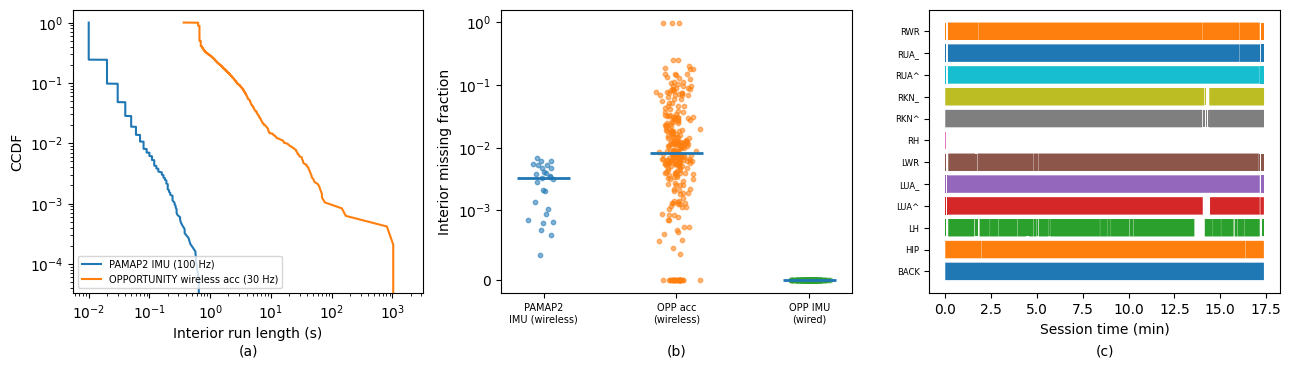

saved: fig/fig1_dropout_characterization.{png,pdf} + 3 CSVs


In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))

# ---------- (a) CCDF of interior run lengths ----------
p_runs = pd.read_csv(os.path.join(DIRS["output"], "pamap2_run_lengths.csv"))
o_runs = pd.read_csv(os.path.join(DIRS["output"],
                                  "opportunity_run_lengths.csv"))
o_int = o_runs[(o_runs["kind"] == "Accelerometer") & (~o_runs["boundary"])]

ccdf_rows = []
for label, series in [("PAMAP2 IMU (100 Hz)", p_runs["run_s"]),
                      ("OPPORTUNITY wireless acc (30 Hz)", o_int["run_s"])]:
    x = np.sort(series.to_numpy())
    y = 1.0 - np.arange(1, len(x) + 1) / len(x)
    axes[0].loglog(x, y, lw=1.5, label=label)
    ccdf_rows.append(pd.DataFrame({"series": label, "run_s": x, "ccdf": y}))
pd.concat(ccdf_rows).to_csv(os.path.join(DIRS["fig"], "fig1_a_ccdf.csv"),
                            index=False)
axes[0].set_xlabel("Interior run length (s)")
axes[0].set_ylabel("CCDF")
axes[0].legend(fontsize=7, loc="lower left")

# ---------- (b) per-recording interior missing fraction ----------
p_stats = pd.read_csv(os.path.join(DIRS["output"], "pamap2_dropout_stats.csv"))
o_stats = pd.read_csv(os.path.join(DIRS["output"],
                                   "opportunity_dropout_stats.csv"))
groups = {
    "PAMAP2\nIMU (wireless)": p_stats["missing_frac"],
    "OPP acc\n(wireless)": o_stats.loc[o_stats["kind"] == "Accelerometer",
                                       "interior_missing_frac"],
    "OPP IMU\n(wired)": o_stats.loc[
        o_stats["kind"] == "InertialMeasurementUnit",
        "interior_missing_frac"],
}
rng = np.random.default_rng(SEED)
box_rows = []
for i, (label, vals) in enumerate(groups.items()):
    v = vals.to_numpy()
    axes[1].scatter(rng.normal(i, 0.06, len(v)), v, s=10, alpha=0.55)
    axes[1].hlines(np.median(v), i - 0.2, i + 0.2, lw=2)
    box_rows.append(pd.DataFrame({"group": label.replace("\n", " "),
                                  "missing_frac": v}))
pd.concat(box_rows).to_csv(os.path.join(DIRS["fig"],
                           "fig1_b_missing_frac.csv"), index=False)
axes[1].set_yscale("symlog", linthresh=1e-3)
axes[1].set_xticks(range(len(groups)), groups.keys(), fontsize=7)
axes[1].set_ylabel("Interior missing fraction")

# ---------- (c) availability raster: S2-ADL5 ----------
sess_path = glob.glob(os.path.join(DIRS["dataset"], "opportunity", "**",
                                   "S2-ADL5.dat"), recursive=True)[0]
df_s = pd.read_csv(sess_path, sep=r"\s+", header=None)
t = np.arange(len(df_s)) / FS_OPP / 60.0  # minutes
raster_rows = []
show = [d for d in sorted(body) if d.startswith("Accelerometer")]
for j, dev in enumerate(show):
    nan = np.isnan(df_s[body[dev]].to_numpy()).any(axis=1)
    axes[2].fill_between(t, j + 0.1, j + 0.9, where=~nan,
                         step="mid", lw=0)
    raster_rows.append(pd.DataFrame(
        {"device": dev.split()[-1], "t_min": t, "available": (~nan)}))
pd.concat(raster_rows).to_csv(os.path.join(DIRS["fig"],
                              "fig1_c_raster.csv"), index=False)
axes[2].set_yticks([j + 0.5 for j in range(len(show))],
                   [d.split()[-1] for d in show], fontsize=6)
axes[2].set_xlabel("Session time (min)")

for ax, lab in zip(axes, ["(a)", "(b)", "(c)"]):
    ax.text(0.5, PANEL_LABEL_Y, lab, transform=ax.transAxes,
            ha="center", va="top", fontsize=10)

fig.tight_layout()
for ext in ("png", "pdf"):
    fig.savefig(os.path.join(DIRS["fig"], f"fig1_dropout_characterization.{ext}"),
                dpi=FIG_DPI, bbox_inches="tight")
plt.show()
print("saved: fig/fig1_dropout_characterization.{png,pdf} + 3 CSVs")

## Burst run-length model fitting

We fit candidate parametric models to the *burst-regime* interior run lengths:
shifted geometric, discretized log-normal, and discretized Pareto (heavy-tail
check). The three catastrophic device x session pairs identified in Phase 0
belong to the persistent regime and are excluded from burst fitting.

Model comparison is by AIC (log-likelihoods computed on run lengths in
samples); parameter uncertainty by nonparametric bootstrap (1000 resamples,
95% percentile CIs). Outputs: `output/burst_fit_params.csv` and a fit-quality
table printed for inspection. The winning family per dataset becomes the
burst-duration generator of the simulator (C1).

In [6]:
from scipy import stats as st

CATASTROPHIC = {("S2-ADL5", "Accelerometer RH"),
                ("S1-Drill", "Accelerometer RWR"),
                ("S4-ADL3", "Accelerometer LH")}
N_BOOT = 1000

p_runs = pd.read_csv(os.path.join(DIRS["output"], "pamap2_run_lengths.csv"))
o_runs = pd.read_csv(os.path.join(DIRS["output"],
                                  "opportunity_run_lengths.csv"))
o_b = o_runs[(o_runs["kind"] == "Accelerometer") & (~o_runs["boundary"])]
o_b = o_b[~o_b.apply(lambda r: (r["session"], r["device"])
                     in CATASTROPHIC, axis=1)]

burst_sets = {
    "pamap2":      p_runs["run_samples"].to_numpy(),
    "opportunity": o_b["run_samples"].to_numpy(),
}

def ll_geom(k, p):            # shifted geometric, support k >= 1
    return np.sum(st.geom.logpmf(k, p))

def ll_disc(k, dist):         # discretize a continuous dist on k >= 1
    lo = dist.cdf(k - 0.5); hi = dist.cdf(np.maximum(k, 1) + 0.5)
    pr = np.clip(hi - lo, 1e-300, None)
    return np.sum(np.log(pr))

def fit_once(k):
    out = {}
    p_hat = 1.0 / k.mean()
    out["geometric"] = (ll_geom(k, p_hat), {"p": p_hat})
    logk = np.log(k)
    mu, sig = logk.mean(), logk.std(ddof=1)
    out["lognormal"] = (ll_disc(k, st.lognorm(s=sig, scale=np.exp(mu))),
                        {"mu": mu, "sigma": sig})
    alpha = 1.0 + len(k) / np.sum(np.log(k / 0.5))   # Hill-type, xmin=0.5
    out["pareto"] = (ll_disc(k, st.pareto(b=alpha, scale=0.5)),
                     {"alpha": alpha})
    return out

rows = []
for name, k in burst_sets.items():
    fits = fit_once(k)
    n = len(k)
    print(f"\n=== {name}: n={n} burst runs ===")
    for model, (ll, params) in fits.items():
        n_par = len(params)
        aic = 2 * n_par - 2 * ll
        # bootstrap CIs for this model's params
        boot = {q: [] for q in params}
        rng = np.random.default_rng(SEED)
        for _ in range(N_BOOT):
            kb = rng.choice(k, size=n, replace=True)
            for q, v in fit_once(kb)[model][1].items():
                boot[q].append(v)
        ci = {q: (float(np.percentile(b, 2.5)),
                  float(np.percentile(b, 97.5)))
              for q, b in boot.items()}
        row = {"dataset": name, "model": model, "n_runs": n,
               "loglik": ll, "aic": aic,
               **{f"{q}_hat": v for q, v in params.items()},
               **{f"{q}_ci": f"[{lo:.4g}, {hi:.4g}]"
                  for q, (lo, hi) in ci.items()}}
        rows.append(row)
        print(f"  {model:10s} AIC={aic:12.1f}  " +
              "  ".join(f"{q}={v:.4g} CI{ci[q]}" for q, v in params.items()))

fit_df = pd.DataFrame(rows)
fit_df.to_csv(os.path.join(DIRS["output"], "burst_fit_params.csv"),
              index=False)
best = fit_df.loc[fit_df.groupby("dataset")["aic"].idxmin(),
                  ["dataset", "model", "aic"]]
print("\nAIC winners:")
print(best.to_string(index=False))


=== pamap2: n=18557 burst runs ===
  geometric  AIC=     36767.6  p=0.6522 CI(0.640137707217073, 0.6640324127833728)
  lognormal  AIC=     41725.3  mu=0.2399 CI(0.23301844785840892, 0.2462399131986831)  sigma=0.4844 CI(0.4742965518876983, 0.49484529500243896)
  pareto     AIC=     35895.7  alpha=2.072 CI(2.064523886531613, 2.0797204834682588)

=== opportunity: n=4787 burst runs ===
  geometric  AIC=     46882.1  p=0.02011 CI(0.018454606900933757, 0.02177672627624868)
  lognormal  AIC=     42841.3  mu=3.39 CI(3.370765137989962, 3.4097874303072118)  sigma=0.7154 CI(0.6872815096387584, 0.7453217496699235)
  pareto     AIC=     79028.6  alpha=1.245 CI(1.2437279885857988, 1.246068301089316)

AIC winners:
    dataset     model          aic
opportunity lognormal 42841.309648
     pamap2    pareto 35895.673690


## Figure 2 - Fitted burst models vs empirical CCDFs

Two panels: (a) PAMAP2, (b) OPPORTUNITY. Empirical CCDF of burst-regime run
lengths with all three fitted model CCDFs overlaid (winner solid, others
dashed). This is the visual justification for the simulator's burst-duration
generators and for rejecting the memoryless (geometric ~ i.i.d. Bernoulli)
assumption implicit in random-masking evaluation.

Model CCDFs are computed on the integer support (samples) and converted to
seconds at each dataset's sampling rate. Data exported to fig/fig2_*.csv;
PNG+PDF at 300 dpi, no in-figure titles, panel labels below the x-axis.

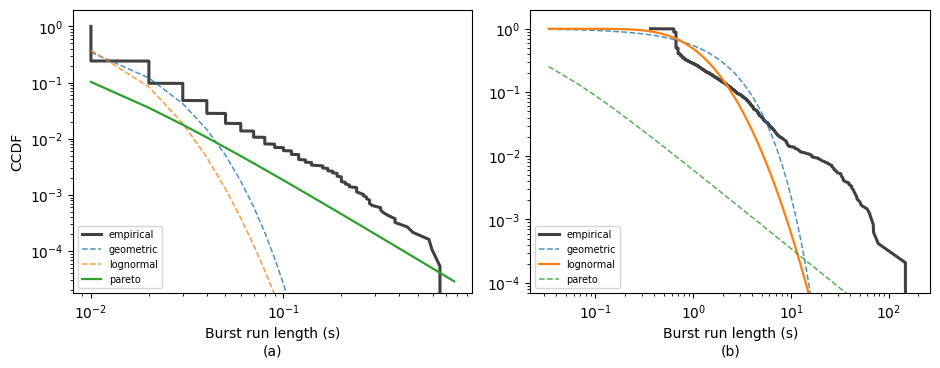

saved: fig/fig2_burst_fits.{png,pdf} + fig2_fit_ccdf.csv


In [7]:

def model_ccdf(kmax, model, prm):
    k = np.arange(1, kmax + 1)
    if model == "geometric":
        cdf = st.geom.cdf(k, prm["p"])
    elif model == "lognormal":
        d = st.lognorm(s=prm["sigma"], scale=np.exp(prm["mu"]))
        cdf = d.cdf(k + 0.5) - d.cdf(0.5)
        cdf = cdf / (1 - d.cdf(0.5))          # renormalize to k >= 1
    elif model == "pareto":
        d = st.pareto(b=prm["alpha"], scale=0.5)
        cdf = d.cdf(k + 0.5)                  # support already k >= 1 region
    return k, 1.0 - cdf

fit_df = pd.read_csv(os.path.join(DIRS["output"], "burst_fit_params.csv"))
WINNER = {"pamap2": "pareto", "opportunity": "lognormal"}

fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.8))
export = []
for ax, (name, k_emp) in zip(axes, burst_sets.items()):
    fs = FS[name]
    x = np.sort(k_emp); y = 1.0 - np.arange(1, len(x) + 1) / len(x)
    ax.loglog(x / fs, y, lw=2.2, color="0.25", label="empirical")
    export.append(pd.DataFrame({"dataset": name, "series": "empirical",
                                "run_s": x / fs, "ccdf": y}))
    sub = fit_df[fit_df["dataset"] == name]
    for _, r in sub.iterrows():
        prm = {c[:-4]: r[c] for c in sub.columns
               if c.endswith("_hat") and pd.notna(r[c])}
        km, cc = model_ccdf(int(k_emp.max()), r["model"], prm)
        keep = cc > 1e-6
        style = dict(lw=1.6) if r["model"] == WINNER[name] \
            else dict(lw=1.1, ls="--", alpha=0.8)
        ax.loglog(km[keep] / fs, cc[keep], label=r["model"], **style)
        export.append(pd.DataFrame({"dataset": name, "series": r["model"],
                                    "run_s": km[keep] / fs,
                                    "ccdf": cc[keep]}))
    ax.set_xlabel("Burst run length (s)")
    ax.set_ylim(bottom=max(1.0 / len(x) / 3, 1e-6))
    ax.legend(fontsize=7, loc="lower left")
axes[0].set_ylabel("CCDF")

for ax, lab in zip(axes, ["(a)", "(b)"]):
    ax.text(0.5, PANEL_LABEL_Y, lab, transform=ax.transAxes,
            ha="center", va="top", fontsize=10)

pd.concat(export).to_csv(os.path.join(DIRS["fig"], "fig2_fit_ccdf.csv"),
                         index=False)
fig.tight_layout()
for ext in ("png", "pdf"):
    fig.savefig(os.path.join(DIRS["fig"], f"fig2_burst_fits.{ext}"),
                dpi=FIG_DPI, bbox_inches="tight")
plt.show()
print("saved: fig/fig2_burst_fits.{png,pdf} + fig2_fit_ccdf.csv")

## OPPORTUNITY tail: spliced lognormal-body + Pareto-tail model

Single-family fits fail on OPPORTUNITY: lognormal wins AIC on the body but
underestimates the tail beyond ~10 s. We fit a spliced model: lognormal below
a tail threshold u, Pareto above it. The threshold is selected by scanning
candidate u values (empirical quantiles 0.90-0.99) and minimizing the
Kolmogorov-Smirnov distance of the tail exceedances to the fitted Pareto
(CSN-style xmin selection, applied to the tail only). We report the spliced
model's AIC against the single-family fits for an honest comparison.

     u  n_tail  alpha  ks_tail        aic
 83.00     471 2.3731   0.2153 40015.9033
 93.00     426 2.4604   0.1685 40171.9085
102.00     381 2.4985   0.1502 40383.0333
111.00     333 2.4877   0.1459 40633.7084
120.84     288 2.4589   0.1411 40861.4385
135.00     239 2.4174   0.1626 41083.3899
152.12     192 2.3393   0.1916 41298.2975
180.42     144 2.2522   0.2344 41511.7801
229.28      96 2.1087   0.3112 41741.5458
486.56      48 2.3009   0.3727 42011.8713

BEST (min KS): u=121 samples (4.03 s), tail weight=0.060, alpha=2.459, AIC=40861.4
single-family AICs -> lognormal: 42841.3, geometric: 46882.1


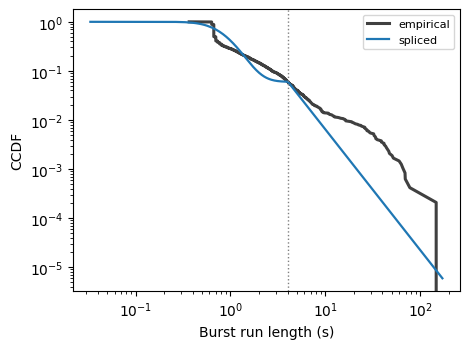

In [8]:
k_opp = burst_sets["opportunity"].astype(float)

def fit_splice(k, u):
    body, tail = k[k <= u], k[k > u]
    w = len(tail) / len(k)
    lb = np.log(body)
    mu, sig = lb.mean(), lb.std(ddof=1)
    alpha = 1.0 + len(tail) / np.sum(np.log(tail / u))
    # log-likelihood: mixture weight + truncated components
    dln = st.lognorm(s=sig, scale=np.exp(mu))
    ll_body = (np.sum(np.log(np.clip(
        dln.cdf(body + 0.5) - dln.cdf(body - 0.5), 1e-300, None)))
        - len(body) * np.log(max(dln.cdf(u), 1e-300)))
    dpar = st.pareto(b=alpha, scale=u)
    ll_tail = np.sum(np.log(np.clip(
        dpar.cdf(tail + 0.5) - dpar.cdf(tail - 0.5), 1e-300, None)))
    ll = (len(body) * np.log(1 - w) + len(tail) * np.log(w)
          + ll_body + ll_tail)
    # KS distance on tail exceedances
    xs = np.sort(tail)
    emp = np.arange(1, len(xs) + 1) / len(xs)
    ks = np.max(np.abs(emp - dpar.cdf(xs)))
    return {"u": u, "w_tail": w, "mu": mu, "sigma": sig,
            "alpha": alpha, "loglik": ll, "aic": 2 * 5 - 2 * ll,
            "ks_tail": ks, "n_tail": len(tail)}

cands = [fit_splice(k_opp, float(np.quantile(k_opp, q)))
         for q in np.arange(0.90, 0.995, 0.01)]
sp = pd.DataFrame(cands)
best = sp.loc[sp["ks_tail"].idxmin()]
sp.to_csv(os.path.join(DIRS["output"], "opportunity_splice_scan.csv"),
          index=False)

print(sp[["u", "n_tail", "alpha", "ks_tail", "aic"]].round(4).to_string(index=False))
print(f"\nBEST (min KS): u={best['u']:.0f} samples "
      f"({best['u']/30:.2f} s), tail weight={best['w_tail']:.3f}, "
      f"alpha={best['alpha']:.3f}, AIC={best['aic']:.1f}")
print(f"single-family AICs -> lognormal: 42841.3, geometric: 46882.1")

# quick visual check of the splice against the empirical CCDF
xs = np.sort(k_opp); ys = 1 - np.arange(1, len(xs) + 1) / len(xs)
u, w = best["u"], best["w_tail"]
dln = st.lognorm(s=best["sigma"], scale=np.exp(best["mu"]))
dpar = st.pareto(b=best["alpha"], scale=u)
kk = np.arange(1, int(k_opp.max()) + 1)
ccdf = np.where(kk <= u,
                1 - (1 - w) * dln.cdf(kk) / dln.cdf(u),
                w * (1 - dpar.cdf(kk)))
plt.figure(figsize=(4.8, 3.6))
plt.loglog(xs / 30, ys, lw=2.2, color="0.25", label="empirical")
plt.loglog(kk / 30, ccdf, lw=1.6, label="spliced")
plt.axvline(u / 30, ls=":", lw=1, color="0.5")
plt.xlabel("Burst run length (s)"); plt.ylabel("CCDF")
plt.legend(fontsize=8); plt.tight_layout(); plt.show()

## Candidate third dataset - MHEALTH raw profiling

MHEALTH (UCI 319): 10 subjects, 12 activities, three wireless Shimmer2
devices (chest, left ankle, right wrist) at 50 Hz. We download the raw logs
and run the same dropout profiling as Phase 0 (device-level NaN runs,
interior/boundary split). Decision rule: MHEALTH is adopted as the third
benchmark dataset regardless of whether it contains natural dropout (the
simulator injects failures); natural dropout, if present, additionally
extends the calibration to a third transport stack.

In [9]:
fetch("mhealth",
      "https://archive.ics.uci.edu/static/public/319/mhealth+dataset.zip")

mh_files = sorted(glob.glob(os.path.join(
    DIRS["dataset"], "mhealth", "**", "mHealth_subject*.log"),
    recursive=True))
print(f"{len(mh_files)} subject logs found")

FS_MH = 50
# column layout (0-based), per dataset README:
# 0-2 chest acc; 3-4 ECG leads; 5-7 LA acc; 8-10 LA gyro; 11-13 LA mag;
# 14-16 RW acc; 17-19 RW gyro; 20-22 RW mag; 23 label
MH_BLOCKS = {
    "chest_acc":   list(range(0, 3)),
    "left_ankle":  list(range(5, 14)),
    "right_wrist": list(range(14, 23)),
}

mh_rows = []
for path in mh_files:
    subj = os.path.basename(path).replace("mHealth_", "").replace(".log", "")
    df = pd.read_csv(path, sep=r"\s+", header=None)
    n = len(df)
    for dev, cols in MH_BLOCKS.items():
        block = df[cols].to_numpy()
        any_nan = np.isnan(block).any(axis=1)
        rr = runs_with_position(any_nan)
        interior = [L for L, b in rr if not b]
        mh_rows.append({
            "subject": subj, "device": dev, "n_samples": n,
            "missing_frac": any_nan.mean(),
            "interior_missing_frac": (sum(interior) / n) if n else 0.0,
            "n_interior_runs": len(interior),
            "zeros_frac": float((block == 0).all(axis=1).mean()),
        })

mh = pd.DataFrame(mh_rows)
mh.to_csv(os.path.join(DIRS["output"], "mhealth_dropout_stats.csv"),
          index=False)
print(mh.groupby("device")[["missing_frac", "interior_missing_frac",
                            "n_interior_runs", "zeros_frac"]]
      .mean().round(5))
print(f"\ntotal samples: {mh['n_samples'].sum():,}")

10 subject logs found
             missing_frac  interior_missing_frac  n_interior_runs  zeros_frac
device                                                                       
chest_acc             0.0                    0.0              0.0         0.0
left_ankle            0.0                    0.0              0.0         0.0
right_wrist           0.0                    0.0              0.0         0.0

total samples: 3,647,235


## Inter-burst gap (availability duration) statistics

The burst regime will be generated as an alternating ON/OFF renewal process:
OFF durations (dropouts) follow the fitted models (D1); ON durations
(availability gaps between consecutive interior dropouts) are measured here.
For each recording x device we extract gap lengths between consecutive
interior runs, pool per dataset, and fit the same candidate families
(shifted geometric / discretized lognormal / Pareto) with AIC comparison.
Output: `output/gap_fit_params.csv`, `output/{pamap2,opportunity}_gaps.csv`.

In [10]:
def gap_lengths(mask):
    """ON-durations (samples) between consecutive interior True-runs."""
    if not mask.any():
        return np.array([], dtype=int)
    m = np.concatenate(([0], mask.view(np.int8), [0]))
    d = np.diff(m)
    starts, ends = np.where(d == 1)[0], np.where(d == -1)[0]
    # keep gaps strictly between runs (not before first / after last)
    return starts[1:] - ends[:-1]

gap_sets = {}

# PAMAP2
rows = []
for path in proto:
    subj = os.path.basename(path).replace(".dat", "")
    df = pd.read_csv(path, sep=r"\s+", header=None)
    for imu, cols in IMU_BLOCKS.items():
        g = gap_lengths(np.isnan(df[cols].to_numpy()).any(axis=1))
        rows += [{"subject": subj, "device": imu, "gap_samples": int(x),
                  "gap_s": x / FS_PAMAP2} for x in g]
gp = pd.DataFrame(rows)
gp.to_csv(os.path.join(DIRS["output"], "pamap2_gaps.csv"), index=False)
gap_sets["pamap2"] = gp["gap_samples"].to_numpy()

# OPPORTUNITY (body wireless acc, catastrophic pairs excluded)
rows = []
for path in dats:
    sess = os.path.basename(path).replace(".dat", "")
    df = pd.read_csv(path, sep=r"\s+", header=None)
    for dev, cols in body.items():
        if not dev.startswith("Accelerometer"):
            continue
        if (sess, dev) in CATASTROPHIC:
            continue
        g = gap_lengths(np.isnan(df[cols].to_numpy()).any(axis=1))
        rows += [{"session": sess, "device": dev, "gap_samples": int(x),
                  "gap_s": x / FS_OPP} for x in g]
go = pd.DataFrame(rows)
go.to_csv(os.path.join(DIRS["output"], "opportunity_gaps.csv"), index=False)
gap_sets["opportunity"] = go["gap_samples"].to_numpy()

rows = []
for name, k in gap_sets.items():
    fits = fit_once(k.astype(float))
    fs = FS[name]
    print(f"\n=== {name}: n={len(k)} gaps | "
          f"median={np.median(k)/fs:.2f} s, p95={np.percentile(k,95)/fs:.1f} s, "
          f"max={k.max()/fs:.1f} s ===")
    for model, (ll, params) in fits.items():
        aic = 2 * len(params) - 2 * ll
        rows.append({"dataset": name, "model": model, "n": len(k),
                     "aic": aic, **{q: v for q, v in params.items()}})
        print(f"  {model:10s} AIC={aic:12.1f}  " +
              "  ".join(f"{q}={v:.4g}" for q, v in params.items()))

gap_fit = pd.DataFrame(rows)
gap_fit.to_csv(os.path.join(DIRS["output"], "gap_fit_params.csv"), index=False)
print("\nAIC winners:")
print(gap_fit.loc[gap_fit.groupby("dataset")["aic"].idxmin(),
                  ["dataset", "model", "aic"]].to_string(index=False))


=== pamap2: n=18530 gaps | median=0.54 s, p95=19.3 s, max=790.2 s ===
  geometric  AIC=    263661.1  p=0.002208
  lognormal  AIC=    221940.8  mu=3.79  sigma=2.182
  pareto     AIC=    335120.8  alpha=1.223

=== opportunity: n=4805 gaps | median=2.40 s, p95=282.3 s, max=2316.4 s ===
  geometric  AIC=     80627.5  p=0.0006174
  lognormal  AIC=     67382.8  mu=4.786  sigma=2.24
  pareto     AIC=    106581.7  alpha=1.183

AIC winners:
    dataset     model           aic
opportunity lognormal  67382.798004
     pamap2 lognormal 221940.847439


## Failure-process simulator (v0.1)

Generates device-level availability masks as an alternating ON/OFF renewal
process, with three regimes:

- `burst`: OFF ~ fitted models (D1: PAMAP2 Pareto / OPP spliced), ON ~ fitted
  lognormal gaps (D3). A `rate_scale` knob multiplies OFF-frequency to sweep
  severity while preserving the empirical shape.
- `persistent`: a device dies at a uniformly random onset time and stays dead
  (battery death; matches natural catastrophic cases F4).
- `gradual`: degradation ramp - increasing noise then loss over a window
  (detachment; literature-calibrated, parameters explicit and marked as such).
- `iid`: Bernoulli masking at rate p - the literature's protocol, included as
  the comparison condition, NOT as a realism claim.

All regimes operate per device (F1: packet-level agreement = 1.0) and return
a boolean availability matrix [n_samples x n_devices] plus an event log for
reproducibility. Unit checks at the end verify that generated run-length and
gap distributions match the fitted targets (KS on log-scale).

In [11]:
# ---- failure_sim.py (v0.2) - will be exported to model/ for reuse ----
from dataclasses import dataclass, field

# ---------------- empirical duration pools (frozen generator inputs) --------
# burst_sets / gap_sets come from cells 12 and 20 (rerun their data-prep
# parts if the kernel was restarted)
EMP_POOLS = {
    "pamap2":      {"off": burst_sets["pamap2"].astype(int),
                    "on":  gap_sets["pamap2"].astype(int)},
    "opportunity": {"off": burst_sets["opportunity"].astype(int),
                    "on":  gap_sets["opportunity"].astype(int)},
}

# ---------------- generator configuration -----------------------------------
# Generation is TRACE-DRIVEN (empirical resampling, D4). The parametric fits
# (D1/D3) remain available as a portable fallback for users without traces.
BURST_PARAMS = {
    "pamap2": {
        "fs": 100,
        "off": ("empirical", {"pool": EMP_POOLS["pamap2"]["off"]}),
        "on":  ("empirical", {"pool": EMP_POOLS["pamap2"]["on"]}),
    },
    "opportunity": {
        "fs": 30,
        "off": ("empirical", {"pool": EMP_POOLS["opportunity"]["off"]}),
        "on":  ("empirical", {"pool": EMP_POOLS["opportunity"]["on"]}),
    },
}

PARAMETRIC_FALLBACK = {   # frozen from D1/D3 - characterization tables
    "pamap2": {
        "off": ("pareto",    {"alpha": 2.072, "xmin": 0.5}),
        "on":  ("lognormal", {"mu": 3.79, "sigma": 2.182}),
    },
    "opportunity": {
        "off": ("splice",    {"mu": 3.39, "sigma": 0.7154,
                              "u": 121, "alpha": 2.459, "w_tail": 0.060}),
        "on":  ("lognormal", {"mu": 4.786, "sigma": 2.24}),
    },
}

def _draw(dist, prm, rng, size):
    """Draw `size` positive integer durations (samples) from a duration model."""
    if dist == "empirical":
        return rng.choice(prm["pool"], size=size)
    if dist == "pareto":
        x = st.pareto(b=prm["alpha"], scale=prm["xmin"]).rvs(
            size, random_state=rng)
    elif dist == "lognormal":
        x = st.lognorm(s=prm["sigma"], scale=np.exp(prm["mu"])).rvs(
            size, random_state=rng)
    elif dist == "splice":
        tail = rng.random(size) < prm["w_tail"]
        x = np.empty(size)
        body = st.lognorm(s=prm["sigma"], scale=np.exp(prm["mu"]))
        qb = rng.random(int((~tail).sum())) * body.cdf(prm["u"])
        x[~tail] = body.ppf(qb)
        x[tail] = st.pareto(b=prm["alpha"], scale=prm["u"]).rvs(
            int(tail.sum()), random_state=rng)
    return np.maximum(np.round(x).astype(int), 1)

@dataclass
class FailureSim:
    regime: str                  # burst | persistent | gradual | iid
    calibration: str = "pamap2"  # which empirical parameter set (burst)
    mode: str = "empirical"      # empirical (D4 default) | parametric
    rate_scale: float = 1.0      # burst severity knob (scales OFF frequency)
    iid_p: float = 0.1
    persistent_onset: tuple = (0.0, 1.0)   # uniform range, fraction of session
    gradual_window_s: float = 60.0         # literature-calibrated, explicit
    seed: int = SEED
    events: list = field(default_factory=list)

    def _durations(self, which):
        if self.mode == "empirical":
            return BURST_PARAMS[self.calibration][which]
        return PARAMETRIC_FALLBACK[self.calibration][which]

    def mask(self, n_samples, n_devices, affected=None):
        """True = available. affected: device indices the regime hits
        (default: all for burst/iid; one random device otherwise)."""
        rng = np.random.default_rng(self.seed)
        m = np.ones((n_samples, n_devices), dtype=bool)
        fs = BURST_PARAMS[self.calibration]["fs"]
        if affected is None:
            affected = (range(n_devices) if self.regime in ("burst", "iid")
                        else [rng.integers(n_devices)])
        for d in affected:
            if self.regime == "iid":
                m[:, d] = rng.random(n_samples) >= self.iid_p
            elif self.regime == "burst":
                off_dist, off_prm = self._durations("off")
                on_dist, on_prm = self._durations("on")
                t = 0
                while t < n_samples:
                    on = int(_draw(on_dist, on_prm, rng, 1)[0])
                    on = max(int(on / self.rate_scale), 1)
                    off = int(_draw(off_dist, off_prm, rng, 1)[0])
                    m[t + on: t + on + off, d] = False
                    self.events.append((int(d), int(t + on), int(off)))
                    t += on + off
            elif self.regime == "persistent":
                lo, hi = self.persistent_onset
                onset = int(rng.uniform(lo, hi) * n_samples)
                m[onset:, d] = False
                self.events.append((int(d), onset, n_samples - onset))
            elif self.regime == "gradual":
                w = int(self.gradual_window_s * fs)
                onset = int(rng.uniform(0.1, 0.9) * n_samples)
                span = min(w, n_samples - onset)
                ramp = np.arange(span) / max(w, 1)
                drop = rng.random(span) < ramp
                seg = m[onset:onset + span, d]
                seg[drop] = False
                m[onset:onset + span, d] = seg
                m[onset + w:, d] = False
                self.events.append((int(d), onset, n_samples - onset))
        return m

# ---- unit checks: generated burst regime vs empirical targets --------------
HOURS = {"pamap2": 3, "opportunity": 12}
for cal in ("pamap2", "opportunity"):
    fs = BURST_PARAMS[cal]["fs"]
    sim = FailureSim("burst", calibration=cal, seed=SEED)
    m = sim.mask(n_samples=fs * 3600 * HOURS[cal], n_devices=1)
    gen_off = run_lengths(~m[:, 0])
    gen_on = gap_lengths(~m[:, 0])
    emp_off = EMP_POOLS[cal]["off"]; emp_on = EMP_POOLS[cal]["on"]
    ks_off = st.ks_2samp(np.log(gen_off), np.log(emp_off)).statistic
    ks_on = st.ks_2samp(np.log(gen_on), np.log(emp_on)).statistic
    print(f"{cal}: gen missing={100*(~m).mean():.2f}%  "
          f"n_cycles={len(gen_off)}  KS(log OFF)={ks_off:.3f}  "
          f"KS(log ON)={ks_on:.3f}")

pamap2: gen missing=0.35%  n_cycles=2425  KS(log OFF)=0.006  KS(log ON)=0.021
opportunity: gen missing=2.05%  n_cycles=632  KS(log OFF)=0.040  KS(log ON)=0.039


## Export simulator module + Figure 3 (regime gallery)

The simulator is exported to `model/failure_sim.py` as a standalone module
(Phase 2 imports it; the paper's code release ships it). Figure 3 shows one
availability raster per regime (burst / persistent / gradual / iid) on an
identical 30-min, 3-device canvas - the visual definition of the evaluation
protocols. Same canvas + same seed makes the contrast between i.i.d.
confetti and structured failures immediately readable.

exported: /kaggle/working/model/failure_sim.py (137 lines)
module smoke test: mask (54000, 3), missing 2.07%
consistency (same seed): identical=True


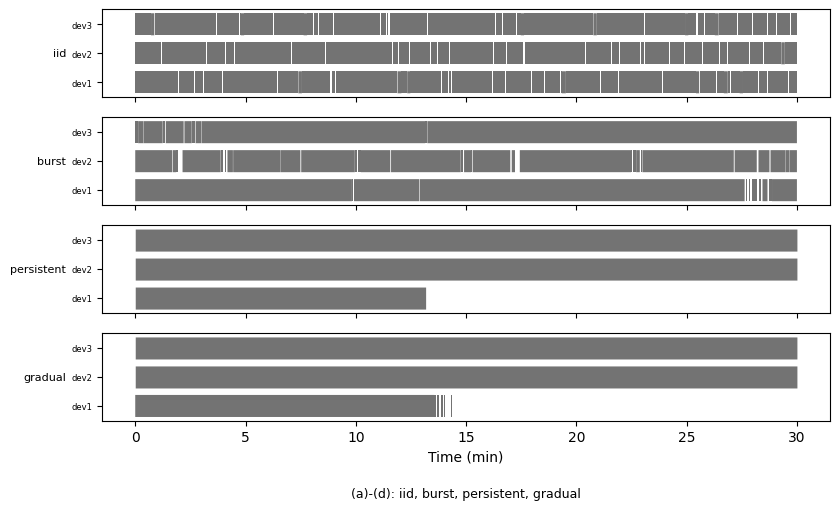

saved: fig/fig3_regime_gallery.{png,pdf} + fig3_regimes.csv


In [12]:
# ---- export model/failure_sim.py (self-contained, v0.2 frozen) -------------
module_src = '''"""
failure_sim.py - device-level sensor-failure simulator for wearable HAR.
v0.2 (frozen). Trace-driven generation (D4); parametric fallback (D1/D3).
Empirical pools are loaded from the run/gap CSVs produced in Phase 0/1.
"""
import numpy as np
import pandas as pd
from dataclasses import dataclass, field
from scipy import stats as st

SEED = 42
FS = {"pamap2": 100, "opportunity": 30}

CATASTROPHIC = {("S2-ADL5", "Accelerometer RH"),
                ("S1-Drill", "Accelerometer RWR"),
                ("S4-ADL3", "Accelerometer LH")}

PARAMETRIC_FALLBACK = {
    "pamap2": {"off": ("pareto", {"alpha": 2.072, "xmin": 0.5}),
               "on": ("lognormal", {"mu": 3.79, "sigma": 2.182})},
    "opportunity": {"off": ("splice", {"mu": 3.39, "sigma": 0.7154,
                                       "u": 121, "alpha": 2.459,
                                       "w_tail": 0.060}),
                    "on": ("lognormal", {"mu": 4.786, "sigma": 2.24})},
}

BURST_PARAMS = None  # set by make_sim / set_pools


def load_pools(output_dir):
    p_runs = pd.read_csv(f"{output_dir}/pamap2_run_lengths.csv")
    o_runs = pd.read_csv(f"{output_dir}/opportunity_run_lengths.csv")
    o_b = o_runs[(o_runs["kind"] == "Accelerometer") & (~o_runs["boundary"])]
    o_b = o_b[~o_b.apply(lambda r: (r["session"], r["device"])
                         in CATASTROPHIC, axis=1)]
    p_gaps = pd.read_csv(f"{output_dir}/pamap2_gaps.csv")
    o_gaps = pd.read_csv(f"{output_dir}/opportunity_gaps.csv")
    return {
        "pamap2": {"off": p_runs["run_samples"].to_numpy(int),
                   "on":  p_gaps["gap_samples"].to_numpy(int)},
        "opportunity": {"off": o_b["run_samples"].to_numpy(int),
                        "on":  o_gaps["gap_samples"].to_numpy(int)},
    }


def set_pools(pools):
    global BURST_PARAMS
    BURST_PARAMS = {
        c: {"fs": FS[c],
            "off": ("empirical", {"pool": pools[c]["off"]}),
            "on":  ("empirical", {"pool": pools[c]["on"]})}
        for c in pools}


def _draw(dist, prm, rng, size):
    """Draw `size` positive integer durations (samples)."""
    if dist == "empirical":
        return rng.choice(prm["pool"], size=size)
    if dist == "pareto":
        x = st.pareto(b=prm["alpha"], scale=prm["xmin"]).rvs(
            size, random_state=rng)
    elif dist == "lognormal":
        x = st.lognorm(s=prm["sigma"], scale=np.exp(prm["mu"])).rvs(
            size, random_state=rng)
    elif dist == "splice":
        tail = rng.random(size) < prm["w_tail"]
        x = np.empty(size)
        body = st.lognorm(s=prm["sigma"], scale=np.exp(prm["mu"]))
        qb = rng.random(int((~tail).sum())) * body.cdf(prm["u"])
        x[~tail] = body.ppf(qb)
        x[tail] = st.pareto(b=prm["alpha"], scale=prm["u"]).rvs(
            int(tail.sum()), random_state=rng)
    return np.maximum(np.round(x).astype(int), 1)


@dataclass
class FailureSim:
    regime: str                  # burst | persistent | gradual | iid
    calibration: str = "pamap2"
    mode: str = "empirical"      # empirical (D4 default) | parametric
    rate_scale: float = 1.0
    iid_p: float = 0.1
    persistent_onset: tuple = (0.0, 1.0)
    gradual_window_s: float = 60.0
    seed: int = SEED
    events: list = field(default_factory=list)

    def _durations(self, which):
        if self.mode == "empirical":
            return BURST_PARAMS[self.calibration][which]
        return PARAMETRIC_FALLBACK[self.calibration][which]

    def mask(self, n_samples, n_devices, affected=None):
        """True = available. affected: device indices hit by the regime
        (default: all for burst/iid; one random device otherwise)."""
        rng = np.random.default_rng(self.seed)
        m = np.ones((n_samples, n_devices), dtype=bool)
        fs = BURST_PARAMS[self.calibration]["fs"]
        if affected is None:
            affected = (range(n_devices) if self.regime in ("burst", "iid")
                        else [rng.integers(n_devices)])
        for d in affected:
            if self.regime == "iid":
                m[:, d] = rng.random(n_samples) >= self.iid_p
            elif self.regime == "burst":
                off_dist, off_prm = self._durations("off")
                on_dist, on_prm = self._durations("on")
                t = 0
                while t < n_samples:
                    on = int(_draw(on_dist, on_prm, rng, 1)[0])
                    on = max(int(on / self.rate_scale), 1)
                    off = int(_draw(off_dist, off_prm, rng, 1)[0])
                    m[t + on: t + on + off, d] = False
                    self.events.append((int(d), int(t + on), int(off)))
                    t += on + off
            elif self.regime == "persistent":
                lo, hi = self.persistent_onset
                onset = int(rng.uniform(lo, hi) * n_samples)
                m[onset:, d] = False
                self.events.append((int(d), onset, n_samples - onset))
            elif self.regime == "gradual":
                w = int(self.gradual_window_s * fs)
                onset = int(rng.uniform(0.1, 0.9) * n_samples)
                span = min(w, n_samples - onset)
                ramp = np.arange(span) / max(w, 1)
                drop = np.zeros(n_samples, dtype=bool)
                drop[onset:onset + span] = rng.random(span) < ramp
                m[drop, d] = False
                m[onset + w:, d] = False
                self.events.append((int(d), onset, n_samples - onset))
        return m


def make_sim(regime, calibration, output_dir, **kw):
    """Factory: loads empirical pools from CSVs and returns a FailureSim."""
    set_pools(load_pools(output_dir))
    return FailureSim(regime, calibration=calibration, **kw)
'''

mod_path = os.path.join(DIRS["model"], "failure_sim.py")
with open(mod_path, "w") as f:
    f.write(module_src)
print(f"exported: {mod_path} ({len(module_src.splitlines())} lines)")

# ---- smoke test in a clean namespace ---------------------------------------
import importlib.util
spec = importlib.util.spec_from_file_location("failure_sim", mod_path)
fsim = importlib.util.module_from_spec(spec); spec.loader.exec_module(fsim)
s = fsim.make_sim("burst", "opportunity", DIRS["output"], seed=SEED)
mt = s.mask(30 * 60 * 30, 3)
print(f"module smoke test: mask {mt.shape}, missing {100*(~mt).mean():.2f}%")

# ---- module-vs-notebook consistency check ----------------------------------
sim_nb = FailureSim("burst", calibration="opportunity", seed=SEED)
m_nb = sim_nb.mask(30 * 60 * 30, 3)
print(f"consistency (same seed): identical={np.array_equal(mt, m_nb)}")

# ---- Figure 3: regime gallery ----------------------------------------------
N_MIN, N_DEV, FS_FIG = 30, 3, 30
n = FS_FIG * 60 * N_MIN
regimes = [("iid", dict(iid_p=0.02)),
           ("burst", {}),
           ("persistent", {}),
           ("gradual", {})]
fig, axes = plt.subplots(4, 1, figsize=(8.5, 5.2), sharex=True)
export = []
t = np.arange(n) / FS_FIG / 60
for ax, (reg, kw) in zip(axes, regimes):
    sim = fsim.make_sim(reg, "opportunity", DIRS["output"], seed=SEED, **kw)
    m = sim.mask(n, N_DEV)
    for j in range(N_DEV):
        ax.fill_between(t, j + 0.12, j + 0.88, where=m[:, j],
                        step="mid", lw=0, color="0.45")
    ax.set_yticks([j + 0.5 for j in range(N_DEV)],
                  [f"dev{j+1}" for j in range(N_DEV)], fontsize=6)
    ax.set_ylabel(reg, fontsize=8, rotation=0, ha="right", va="center")
    export.append(pd.DataFrame(
        {"regime": reg,
         **{f"dev{j+1}": m[:, j] for j in range(N_DEV)},
         "t_min": t}))
axes[-1].set_xlabel("Time (min)")
axes[-1].text(0.5, -0.75, "(a)-(d): iid, burst, persistent, gradual",
              transform=axes[-1].transAxes, ha="center", va="top", fontsize=9)
pd.concat(export).to_csv(os.path.join(DIRS["fig"], "fig3_regimes.csv"),
                         index=False)
fig.tight_layout()
for ext in ("png", "pdf"):
    fig.savefig(os.path.join(DIRS["fig"], f"fig3_regime_gallery.{ext}"),
                dpi=FIG_DPI, bbox_inches="tight")
plt.show()
print("saved: fig/fig3_regime_gallery.{png,pdf} + fig3_regimes.csv")

# Phase 2 - Data pipeline

Shared windowing/normalization utilities + per-dataset preprocessing.
Windows: 2.0 s, 50% overlap, majority label (purity >= 0.5). Devices match
simulator granularity. Natural NaNs are linearly interpolated (the
literature's clean-training assumption, reconstructed deliberately).
Outputs per dataset: `dataset/proc/<name>/S<k>.npz` holding X
[n_win, n_samples, n_ch], y, and per-window subject/session ids, plus a
channel->device map in `output/device_maps.json` and LOSO folds in
`output/splits.json`. Processing order: PAMAP2 first (shape check), then
OPPORTUNITY, then MHEALTH.

In [13]:
import json

WIN_S, OVERLAP, PURITY = 2.0, 0.5, 0.5
PROC = os.path.join(DIRS["dataset"], "proc")
os.makedirs(PROC, exist_ok=True)

def interp_nan(a):
    """Column-wise linear interpolation (edges: nearest valid)."""
    out = a.copy()
    for c in range(out.shape[1]):
        col = out[:, c]; bad = np.isnan(col)
        if bad.all():
            out[:, c] = 0.0
        elif bad.any():
            idx = np.arange(len(col))
            out[bad, c] = np.interp(idx[bad], idx[~bad], col[~bad])
    return out

def windowize(sig, labels, fs, win_s=WIN_S, overlap=OVERLAP,
              purity=PURITY):
    w = int(win_s * fs); step = int(w * (1 - overlap))
    Xs, ys = [], []
    for s in range(0, len(sig) - w + 1, step):
        lab = labels[s:s + w]
        vals, cnt = np.unique(lab, return_counts=True)
        top = np.argmax(cnt)
        if vals[top] <= 0 or cnt[top] / w < purity:
            continue
        Xs.append(sig[s:s + w]); ys.append(vals[top])
    if not Xs:
        return (np.empty((0, int(win_s * fs), sig.shape[1]),
                         dtype=np.float32), np.empty((0,), dtype=np.int64))
    return np.stack(Xs).astype(np.float32), np.array(ys, dtype=np.int64)

device_maps, splits = {}, {}

# ---------------- PAMAP2 ----------------
# per device keep acc16g(3) + gyro(3) + mag(3) = 9 ch (skip temp, acc6g, orient)
P_KEEP = {imu: [cols[1], cols[2], cols[3], cols[7], cols[8], cols[9],
                cols[10], cols[11], cols[12]]
          for imu, cols in IMU_BLOCKS.items()}
p_channels, p_devmap, off = [], {}, 0
for imu in ("hand", "chest", "ankle"):
    p_devmap[imu] = list(range(off, off + 9)); off += 9
    p_channels += P_KEEP[imu]
device_maps["pamap2"] = p_devmap

out_dir = os.path.join(PROC, "pamap2"); os.makedirs(out_dir, exist_ok=True)
p_summary = []
for path in proto:
    subj = os.path.basename(path).replace(".dat", "")
    df = pd.read_csv(path, sep=r"\s+", header=None)
    sig = interp_nan(df[p_channels].to_numpy())
    X, y = windowize(sig, df[1].to_numpy(), FS_PAMAP2)
    np.savez_compressed(os.path.join(out_dir, f"{subj}.npz"), X=X, y=y)
    p_summary.append({"subject": subj, "n_win": len(X),
                      "n_classes": len(np.unique(y))})
ps = pd.DataFrame(p_summary)
splits["pamap2"] = [{"test": [r["subject"]],
                     "train": [s for s in ps["subject"] if s != r["subject"]]}
                    for _, r in ps.iterrows()]
print(ps.to_string(index=False))
print(f"\ntotal windows: {ps['n_win'].sum():,} | "
      f"X shape per window: {X.shape[1:]} | classes overall: "
      f"{sorted(set(np.concatenate([np.load(os.path.join(out_dir, f'{s}.npz'))['y'] for s in ps['subject']])))}")

with open(os.path.join(DIRS["output"], "device_maps.json"), "w") as f:
    json.dump(device_maps, f, indent=1)
with open(os.path.join(DIRS["output"], "splits.json"), "w") as f:
    json.dump(splits, f, indent=1)
print("saved: device_maps.json, splits.json (pamap2 entries)")

   subject  n_win  n_classes
subject101   2503         12
subject102   2631         12
subject103   1743          8
subject104   2314         10
subject105   2723         12
subject106   2501         12
subject107   2325         11
subject108   2621         12
subject109     64          1

total windows: 19,425 | X shape per window: (200, 27) | classes overall: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(12), np.int64(13), np.int64(16), np.int64(17), np.int64(24)]
saved: device_maps.json, splits.json (pamap2 entries)


In [14]:
with open(os.path.join(DIRS["output"], "splits.json")) as f:
    splits = json.load(f)
ALL_P = [f"subject10{i}" for i in range(1, 10)]
splits["pamap2"] = [{"test": [s],
                     "train": [t for t in ALL_P if t != s]}
                    for s in ALL_P if s != "subject109"]
with open(os.path.join(DIRS["output"], "splits.json"), "w") as f:
    json.dump(splits, f, indent=1)
print(f"pamap2 folds: {len(splits['pamap2'])} (subject109 train-only, D6)")

pamap2 folds: 8 (subject109 train-only, D6)


## OPPORTUNITY preprocessing

Input devices = the 7 body IMUs (BACK, RUA, RLA, LUA, LLA, L-SHOE, R-SHOE),
9 channels each: acc+gyro+mag for the five torso/arm IMUs; for the shoes
(different layout) Nav_A + Body_A + AngVelBodyFrame - channel identity is
verified against column_names.txt at runtime and printed. Task = Locomotion
(4 classes; Null dropped by the purity rule since label 0 is excluded).
All six sessions per subject (5 ADL + Drill) are used. Catastrophic
device x session pairs stay in: all-NaN device columns are zero-filled by
`interp_nan` (documented footnote). Windows 2 s / 50% at 30 Hz -> (60, 63).
LOSO folds S1-S4 appended to splits.json.

In [15]:
O_IMUS = ["BACK", "RUA", "RLA", "LUA", "LLA", "L-SHOE", "R-SHOE"]

# full descriptions for verification
col_desc = {}
with open(cn_path) as f:
    for line in f:
        m = re.match(r"Column:\s+(\d+)\s+(.*)", line.strip())
        if m:
            col_desc[int(m.group(1)) - 1] = m.group(2).split(";")[0].strip()
loco_idx = [i for i, d_ in col_desc.items() if d_ == "Locomotion"][0]
print(f"Locomotion label column index: {loco_idx}")

o_channels, o_devmap, off = [], {}, 0
for loc in O_IMUS:
    cols = device_cols[f"InertialMeasurementUnit {loc}"]
    keep = cols[3:12] if "SHOE" in loc else cols[0:9]
    o_devmap[loc] = list(range(off, off + 9)); off += 9
    o_channels += keep
    print(f"{loc}: " + " | ".join(col_desc[c].split()[-2] + "_"
          + col_desc[c].split()[-1] for c in keep[:3])
          + " ... (9 ch)")

device_maps["opportunity"] = o_devmap
with open(os.path.join(DIRS["output"], "device_maps.json"), "w") as f:
    json.dump(device_maps, f, indent=1)

out_dir = os.path.join(PROC, "opportunity"); os.makedirs(out_dir, exist_ok=True)
o_summary = []
for subj in ("S1", "S2", "S3", "S4"):
    Xs, ys = [], []
    for path in [p for p in dats if os.path.basename(p).startswith(subj)]:
        df = pd.read_csv(path, sep=r"\s+", header=None)
        sig = interp_nan(df[o_channels].to_numpy())
        X, y = windowize(sig, df[loco_idx].to_numpy(), FS_OPP)
        Xs.append(X); ys.append(y)
    X = np.concatenate(Xs); y = np.concatenate(ys)
    np.savez_compressed(os.path.join(out_dir, f"{subj}.npz"), X=X, y=y)
    o_summary.append({"subject": subj, "n_win": len(X),
                      "classes": sorted(np.unique(y).tolist())})
osm = pd.DataFrame(o_summary)
print(osm.to_string(index=False))
print(f"total windows: {osm['n_win'].sum():,} | shape: {X.shape[1:]}")

splits["opportunity"] = [{"test": [s],
                          "train": [t for t in ("S1", "S2", "S3", "S4")
                                    if t != s]}
                         for s in ("S1", "S2", "S3", "S4")]
with open(os.path.join(DIRS["output"], "splits.json"), "w") as f:
    json.dump(splits, f, indent=1)
print("splits.json: opportunity folds appended")

Locomotion label column index: 243
BACK: BACK_accX | BACK_accY | BACK_accZ ... (9 ch)
RUA: RUA_accX | RUA_accY | RUA_accZ ... (9 ch)
RLA: RLA_accX | RLA_accY | RLA_accZ ... (9 ch)
LUA: LUA_accX | LUA_accY | LUA_accZ ... (9 ch)
LLA: LLA_accX | LLA_accY | LLA_accZ ... (9 ch)
L-SHOE: L-SHOE_Nav_Ax | L-SHOE_Nav_Ay | L-SHOE_Nav_Az ... (9 ch)
R-SHOE: R-SHOE_Nav_Ax | R-SHOE_Nav_Ay | R-SHOE_Nav_Az ... (9 ch)
subject  n_win      classes
     S1   6221 [1, 2, 4, 5]
     S2   6023 [1, 2, 4, 5]
     S3   6419 [1, 2, 4, 5]
     S4   4892 [1, 2, 4, 5]
total windows: 23,555 | shape: (60, 63)
splits.json: opportunity folds appended


## MHEALTH preprocessing

Three devices, 9 channels each to mirror the other datasets' device blocks:
chest = acc(3) + ECG is excluded (not a motion channel; and 2 leads would
break the uniform 9-ch device block) -> chest uses acc only, padded design
decision: chest device = 3 channels, ankle/wrist = 9 (acc+gyro+mag).
Uniformity across devices is NOT required by the models (channels are
concatenated; the device map records boundaries), so chest keeps its true
3 channels rather than padding. Windows 2 s /

In [16]:
MH_DEV_COLS = {
    "chest":       list(range(0, 3)),            # acc only (ECG excluded)
    "left_ankle":  list(range(5, 14)),           # acc+gyro+mag
    "right_wrist": list(range(14, 23)),          # acc+gyro+mag
}
mh_channels, mh_devmap, off = [], {}, 0
for dev, cols in MH_DEV_COLS.items():
    mh_devmap[dev] = list(range(off, off + len(cols))); off += len(cols)
    mh_channels += cols
device_maps["mhealth"] = mh_devmap
with open(os.path.join(DIRS["output"], "device_maps.json"), "w") as f:
    json.dump(device_maps, f, indent=1)

mh_files = sorted(glob.glob(os.path.join(
    DIRS["dataset"], "mhealth", "**", "mHealth_subject*.log"),
    recursive=True))
out_dir = os.path.join(PROC, "mhealth"); os.makedirs(out_dir, exist_ok=True)
mh_summary = []
for path in mh_files:
    subj = os.path.basename(path).replace("mHealth_", "").replace(".log", "")
    df = pd.read_csv(path, sep=r"\s+", header=None)
    X, y = windowize(df[mh_channels].to_numpy().astype(float),
                     df[23].to_numpy(), FS_MH)
    np.savez_compressed(os.path.join(out_dir, f"{subj}.npz"), X=X, y=y)
    mh_summary.append({"subject": subj, "n_win": len(X),
                       "n_classes": len(np.unique(y))})
ms = pd.DataFrame(mh_summary).sort_values("subject")
print(ms.to_string(index=False))
print(f"total windows: {ms['n_win'].sum():,} | shape: {X.shape[1:]}")

subs = ms["subject"].tolist()
splits["mhealth"] = [{"test": [s], "train": [t for t in subs if t != s]}
                     for s in subs]
with open(os.path.join(DIRS["output"], "splits.json"), "w") as f:
    json.dump(splits, f, indent=1)

# ---- pipeline closing summary ----
print("\n=== DATA PIPELINE SUMMARY ===")
for name in ("pamap2", "opportunity", "mhealth"):
    d = os.path.join(PROC, name)
    files = sorted(glob.glob(os.path.join(d, "*.npz")))
    tot = sum(len(np.load(f)["y"]) for f in files)
    with open(os.path.join(DIRS["output"], "splits.json")) as fh:
        nf = len(json.load(fh)[name])
    print(f"{name:12s} {len(files):2d} subject files | {tot:6,} windows | "
          f"{nf} LOSO folds | devices: {list(device_maps[name])}")

  subject  n_win  n_classes
 subject1    703         12
subject10    672         12
 subject2    710         12
 subject3    708         12
 subject4    706         12
 subject5    680         12
 subject6    646         12
 subject7    685         12
 subject8    666         12
 subject9    689         12
total windows: 6,865 | shape: (100, 21)

=== DATA PIPELINE SUMMARY ===
pamap2        9 subject files | 19,425 windows | 8 LOSO folds | devices: ['hand', 'chest', 'ankle']
opportunity   4 subject files | 23,555 windows | 4 LOSO folds | devices: ['BACK', 'RUA', 'RLA', 'LUA', 'LLA', 'L-SHOE', 'R-SHOE']
mhealth      10 subject files |  6,865 windows | 10 LOSO folds | devices: ['chest', 'left_ankle', 'right_wrist']


# Phase 2.2 - Baseline model + checkpointed LOSO runner

Baseline: DeepConvLSTM-class network (4 temporal conv layers, 64 filters,
kernel 5; 2-layer LSTM 128; dropout 0.5; FC head). One model per fold,
fixed budget 30 epochs, Adam 1e-3, batch 128, per-channel z-score from the
train fold only. No early stopping (no subject-clean validation set in LOSO;
fixed-budget is the standard, documented choice).

Checkpointing: each fold writes `model/ckpt/<ds>_f<k>_<run>.pt` +
norm stats `.npz`; completed folds are skipped on rerun, per-fold clean-test
macro-F1 appended to `output/baseline_results.csv`. Failure-regime evaluation
(Phase 2.3) reloads these checkpoints - training never repeats.

In [17]:
PROC = os.path.join(DIRS["dataset"], "proc")
WIN_S, OVERLAP, PURITY = 2.0, 0.5, 0.5
with open(os.path.join(DIRS["output"], "device_maps.json")) as f:
    device_maps = json.load(f)
with open(os.path.join(DIRS["output"], "splits.json")) as f:
    splits = json.load(f)
print("constants ready | PROC exists:", os.path.exists(PROC),
      "| device_maps:", sorted(device_maps), "| splits:", sorted(splits))

constants ready | PROC exists: True | device_maps: ['mhealth', 'opportunity', 'pamap2'] | splits: ['mhealth', 'opportunity', 'pamap2']


In [18]:
import torch
import torch.nn as nn
from sklearn.metrics import f1_score
import time

DEV = "cuda" if torch.cuda.is_available() else "cpu"
RUN_ID = "seed42"
EPOCHS, BATCH, LR = 30, 128, 1e-3
CKPT = os.path.join(DIRS["model"], "ckpt"); os.makedirs(CKPT, exist_ok=True)
torch.manual_seed(SEED)

class DeepConvLSTM(nn.Module):
    def __init__(self, n_ch, n_cls):
        super().__init__()
        convs, c_in = [], n_ch
        for _ in range(4):
            convs += [nn.Conv1d(c_in, 64, 5, padding=2), nn.ReLU()]
            c_in = 64
        self.conv = nn.Sequential(*convs)
        self.lstm = nn.LSTM(64, 128, num_layers=2, batch_first=True,
                            dropout=0.5)
        self.head = nn.Sequential(nn.Dropout(0.5), nn.Linear(128, n_cls))

    def forward(self, x):            # x: [B, T, C]
        z = self.conv(x.permute(0, 2, 1)).permute(0, 2, 1)
        z, _ = self.lstm(z)
        return self.head(z[:, -1])

def load_subject(ds, subj):
    d = np.load(os.path.join(PROC, ds, f"{subj}.npz"))
    return d["X"], d["y"]

def label_map(ds, subjects):
    ys = np.concatenate([load_subject(ds, s)[1] for s in subjects])
    classes = np.sort(np.unique(ys))
    return {int(c): i for i, c in enumerate(classes)}

def train_fold(ds, fold_i, fold, lmap):
    tag = f"{ds}_f{fold_i}_{RUN_ID}"
    ck = os.path.join(CKPT, f"{tag}.pt")
    if os.path.exists(ck):
        print(f"[skip] {tag} (checkpoint exists)")
        return None
    t0 = time.time()
    Xtr = np.concatenate([load_subject(ds, s)[0] for s in fold["train"]])
    ytr = np.concatenate([load_subject(ds, s)[1] for s in fold["train"]])
    Xte, yte = load_subject(ds, fold["test"][0])
    mu = Xtr.mean(axis=(0, 1), keepdims=True)
    sd = Xtr.std(axis=(0, 1), keepdims=True) + 1e-8
    np.savez(os.path.join(CKPT, f"{tag}_norm.npz"), mu=mu, sd=sd)
    Xtr = (Xtr - mu) / sd; Xte = (Xte - mu) / sd
    ytr_m = np.array([lmap[int(v)] for v in ytr])
    yte_m = np.array([lmap[int(v)] for v in yte])

    model = DeepConvLSTM(Xtr.shape[2], len(lmap)).to(DEV)
    opt = torch.optim.Adam(model.parameters(), lr=LR)
    lossf = nn.CrossEntropyLoss()
    Xt = torch.tensor(Xtr); yt = torch.tensor(ytr_m)
    ds_t = torch.utils.data.TensorDataset(Xt, yt)
    dl = torch.utils.data.DataLoader(ds_t, batch_size=BATCH, shuffle=True,
                                     generator=torch.Generator().manual_seed(SEED))
    model.train()
    for ep in range(EPOCHS):
        for xb, yb in dl:
            opt.zero_grad()
            loss = lossf(model(xb.to(DEV)), yb.to(DEV))
            loss.backward(); opt.step()
    model.eval()
    with torch.no_grad():
        pr = []
        for i in range(0, len(Xte), 512):
            pr.append(model(torch.tensor(Xte[i:i + 512]).to(DEV))
                      .argmax(1).cpu().numpy())
    f1 = f1_score(yte_m, np.concatenate(pr), average="macro")
    torch.save({"state": model.state_dict(), "n_ch": Xtr.shape[2],
                "n_cls": len(lmap), "lmap": lmap}, ck)
    row = {"dataset": ds, "fold": fold_i, "test_subject": fold["test"][0],
           "run": RUN_ID, "macro_f1_clean": f1,
           "sec": round(time.time() - t0)}
    res_path = os.path.join(DIRS["output"], "baseline_results.csv")
    pd.DataFrame([row]).to_csv(res_path, mode="a",
                               header=not os.path.exists(res_path),
                               index=False)
    print(f"[done] {tag}: clean macro-F1={f1:.4f} ({row['sec']} s)")
    return f1

with open(os.path.join(DIRS["output"], "splits.json")) as f:
    splits = json.load(f)
print(f"device: {DEV}")
for ds in ("mhealth", "pamap2", "opportunity"):   # smallest first
    lmap = label_map(ds, {s for fo in splits[ds] for s in fo["train"]}
                     | {s for fo in splits[ds] for s in fo["test"]})
    for i, fold in enumerate(splits[ds]):
        train_fold(ds, i, fold, lmap)

res = pd.read_csv(os.path.join(DIRS["output"], "baseline_results.csv"))
print("\n=== BASELINE SUMMARY (clean test) ===")
print(res.groupby("dataset")["macro_f1_clean"]
      .agg(["count", "mean", "std", "min", "max"]).round(4))

# ---- session constants that later cells depend on --------------------------
PROC = os.path.join(DIRS["dataset"], "proc")
WIN_S, OVERLAP, PURITY = 2.0, 0.5, 0.5
if os.path.exists(os.path.join(DIRS["output"], "device_maps.json")):
    with open(os.path.join(DIRS["output"], "device_maps.json")) as f:
        device_maps = json.load(f)
if os.path.exists(os.path.join(DIRS["output"], "splits.json")) :
    with open(os.path.join(DIRS["output"], "splits.json")) as f:
        splits = json.load(f)
print("constants ready | PROC:", os.path.exists(PROC),
      "| device_maps:", sorted(device_maps) if 'device_maps' in dir() else "-",
      "| splits:", sorted(splits) if 'splits' in dir() else "-")

device: cuda
[skip] mhealth_f0_seed42 (checkpoint exists)
[skip] mhealth_f1_seed42 (checkpoint exists)
[skip] mhealth_f2_seed42 (checkpoint exists)
[skip] mhealth_f3_seed42 (checkpoint exists)
[skip] mhealth_f4_seed42 (checkpoint exists)
[skip] mhealth_f5_seed42 (checkpoint exists)
[skip] mhealth_f6_seed42 (checkpoint exists)
[skip] mhealth_f7_seed42 (checkpoint exists)
[skip] mhealth_f8_seed42 (checkpoint exists)
[skip] mhealth_f9_seed42 (checkpoint exists)
[skip] pamap2_f0_seed42 (checkpoint exists)
[skip] pamap2_f1_seed42 (checkpoint exists)
[skip] pamap2_f2_seed42 (checkpoint exists)
[skip] pamap2_f3_seed42 (checkpoint exists)
[skip] pamap2_f4_seed42 (checkpoint exists)
[skip] pamap2_f5_seed42 (checkpoint exists)
[skip] pamap2_f6_seed42 (checkpoint exists)
[skip] pamap2_f7_seed42 (checkpoint exists)
[skip] opportunity_f0_seed42 (checkpoint exists)
[skip] opportunity_f1_seed42 (checkpoint exists)
[skip] opportunity_f2_seed42 (checkpoint exists)
[skip] opportunity_f3_seed42 (checkpoi

# Phase 2.3 - Failure-regime evaluation harness

Reloads each fold's checkpoint and evaluates the clean-trained baseline under:
burst (rate_scale 1/3/10/30, both calibrations), persistent (one device,
onset ~ U(0.2, 0.8)), gradual (60 s window), and iid MATCHED to each
structured run's realized missing fraction (D9). Masks are generated on a
continuous per-subject timeline and windowed identically to the data (D8);
masked samples are zeroed post-normalization. 3 mask seeds per condition.
Output: `output/eval_results.csv` (dataset, fold, regime, severity, seed,
realized_missing, macro_f1) + paired iid rows.

In [19]:
with open(os.path.join(DIRS["output"], "device_maps.json")) as f:
    device_maps = json.load(f)
with open(os.path.join(DIRS["output"], "splits.json")) as f:
    splits = json.load(f)
PROC = os.path.join(DIRS["dataset"], "proc")
WIN_S, OVERLAP, PURITY = 2.0, 0.5, 0.5

In [20]:
EVAL_CSV = os.path.join(DIRS["output"], "eval_results.csv")
SKIP_BASELINE_EVAL = (os.path.exists(EVAL_CSV)
                      and len(pd.read_csv(EVAL_CSV)) >= 792)

In [21]:
import importlib.util
spec = importlib.util.spec_from_file_location(
    "failure_sim", os.path.join(DIRS["model"], "failure_sim.py"))
fsim = importlib.util.module_from_spec(spec); spec.loader.exec_module(fsim)
fsim.set_pools(fsim.load_pools(DIRS["output"]))

MASK_SEEDS = (0, 1, 2)
CAL = {"pamap2": "pamap2", "opportunity": "opportunity",
       "mhealth": "opportunity"}   # MHEALTH wireless -> OPP calibration
CONDS = ([("burst", {"rate_scale": r}) for r in (1, 3, 10, 30)]
         + [("persistent", {"persistent_onset": (0.2, 0.8)}),
            ("gradual", {})])

def window_mask(cont, n_win, w, step, devmap, n_ch):
    """Continuous [L, n_dev] mask -> per-window per-channel mask."""
    M = np.ones((n_win, w, n_ch), dtype=bool)
    for di, (dev, chans) in enumerate(devmap.items()):
        for k in range(n_win):
            M[k, :, chans] = cont[k * step: k * step + w, di]
    return M

def eval_fold(ds, fold_i, fold):
    tag = f"{ds}_f{fold_i}_{RUN_ID}"
    ck = torch.load(os.path.join(CKPT, f"{tag}.pt"), map_location=DEV,
                    weights_only=False)
    nrm = np.load(os.path.join(CKPT, f"{tag}_norm.npz"))
    model = DeepConvLSTM(ck["n_ch"], ck["n_cls"]).to(DEV)
    model.load_state_dict(ck["state"]); model.eval()
    lmap = ck["lmap"]
    X, y = load_subject(ds, fold["test"][0])
    Xn = (X - nrm["mu"]) / nrm["sd"]
    ym = np.array([lmap[str(int(v))] if isinstance(list(lmap)[0], str)
                   else lmap[int(v)] for v in y])
    devmap = device_maps[ds]
    n_win, w, n_ch = Xn.shape
    step = int(w * (1 - OVERLAP))
    L = step * (n_win - 1) + w
    fs_cal = CAL[ds]

    def f1_masked(M):
        Xm = np.where(M, Xn, 0.0).astype(np.float32)
        pr = []
        with torch.no_grad():
            for i in range(0, len(Xm), 512):
                pr.append(model(torch.tensor(Xm[i:i + 512]).to(DEV))
                          .argmax(1).cpu().numpy())
        return f1_score(ym, np.concatenate(pr), average="macro")

    rows = []
    for regime, kw in CONDS:
        for ms in MASK_SEEDS:
            sim = fsim.FailureSim(regime, calibration=fs_cal,
                                  seed=1000 * fold_i + ms, **kw)
            cont = sim.mask(L, len(devmap))
            M = window_mask(cont, n_win, w, step, devmap, n_ch)
            miss = float((~cont).mean())
            sev = kw.get("rate_scale", "-")
            rows.append({"dataset": ds, "fold": fold_i, "regime": regime,
                         "severity": sev, "mask_seed": ms,
                         "realized_missing": miss,
                         "macro_f1": f1_masked(M)})
            # D9: matched-iid twin
            sim2 = fsim.FailureSim("iid", calibration=fs_cal, iid_p=miss,
                                   seed=1000 * fold_i + ms)
            cont2 = sim2.mask(L, len(devmap))
            M2 = window_mask(cont2, n_win, w, step, devmap, n_ch)
            rows.append({"dataset": ds, "fold": fold_i,
                         "regime": f"iid@{regime}", "severity": sev,
                         "mask_seed": ms,
                         "realized_missing": float((~cont2).mean()),
                         "macro_f1": f1_masked(M2)})
    return rows

if SKIP_BASELINE_EVAL:
    print("baseline eval complete (>=792 rows) - skipping recompute")
    ev = pd.read_csv(EVAL_CSV)
else:
    all_rows = []
    for ds in ("mhealth", "pamap2", "opportunity"):
        for i, fold in enumerate(splits[ds]):
            all_rows += eval_fold(ds, i, fold)
            print(f"{ds} fold {i} done")
    ev = pd.DataFrame(all_rows)
    ev.to_csv(EVAL_CSV, index=False)

print("\n=== STRUCTURED vs MATCHED-IID (macro-F1, mean over folds+seeds) ===")
piv = (ev.assign(base=ev["regime"].str.replace("iid@", ""),
                 kind=np.where(ev["regime"].str.startswith("iid@"),
                               "iid_matched", "structured"))
       .groupby(["dataset", "base", "severity", "kind"])["macro_f1"]
       .mean().unstack().round(4))
piv["gap"] = (piv["iid_matched"] - piv["structured"]).round(4)
print(piv.to_string())

baseline eval complete (>=792 rows) - skipping recompute

=== STRUCTURED vs MATCHED-IID (macro-F1, mean over folds+seeds) ===
kind                             iid_matched  structured     gap
dataset     base       severity                                 
mhealth     burst      1              0.8587      0.8325  0.0262
                       10             0.8447      0.7001  0.1446
                       3              0.8618      0.8017  0.0601
                       30             0.6528      0.4966  0.1562
            gradual    -              0.8536      0.7327  0.1209
            persistent -              0.8562      0.7170  0.1392
opportunity burst      1              0.7375      0.7280  0.0095
                       10             0.7421      0.6789  0.0632
                       3              0.7402      0.7198  0.0204
                       30             0.7312      0.5841  0.1471
            gradual    -              0.7391      0.7230  0.0161
            persistent -     

In [22]:
ev = pd.read_csv(os.path.join(DIRS["output"], "eval_results.csv"))
o = ev[(ev["dataset"] == "opportunity") & (ev["regime"] == "iid@burst")]
print("OPP iid@burst per fold x severity (macro-F1):")
print(o.pivot_table(index="fold", columns="severity",
                    values="macro_f1").round(4))
print("\nrealized missing per severity:")
print(o.groupby("severity")["realized_missing"].mean().round(4))
b = ev[(ev["dataset"] == "opportunity") & (ev["regime"] == "burst")]
print("\nOPP structured burst per fold x severity:")
print(b.pivot_table(index="fold", columns="severity",
                    values="macro_f1").round(4))

OPP iid@burst per fold x severity (macro-F1):
severity       1      10       3      30
fold                                    
0         0.8681  0.8680  0.8695  0.8530
1         0.8461  0.8415  0.8481  0.7900
2         0.5990  0.5929  0.5990  0.5686
3         0.6367  0.6660  0.6443  0.7132

realized missing per severity:
severity
1     0.0325
10    0.2405
3     0.0887
30    0.4858
Name: realized_missing, dtype: float64

OPP structured burst per fold x severity:
severity       1      10       3      30
fold                                    
0         0.8618  0.7930  0.8531  0.6337
1         0.8267  0.7463  0.8188  0.6264
2         0.5888  0.5372  0.5742  0.4698
3         0.6348  0.6392  0.6329  0.6064


In [23]:
ev = pd.read_csv(os.path.join(DIRS["output"], "eval_results.csv"))
ev["severity"] = ev["severity"].fillna("-")
ev = ev.assign(base=ev["regime"].str.replace("iid@", ""),
               kind=np.where(ev["regime"].str.startswith("iid@"),
                             "iid_matched", "structured"))
# median over folds of (mean over mask seeds)
per_fold = (ev.groupby(["dataset", "base", "severity", "kind", "fold"])
            ["macro_f1"].mean().reset_index())
med = (per_fold.groupby(["dataset", "base", "severity", "kind"])["macro_f1"]
       .median().unstack().round(4))
med["gap"] = (med["iid_matched"] - med["structured"]).round(4)
med.to_csv(os.path.join(DIRS["output"], "main_table_median.csv"))
print("=== MAIN TABLE (fold-MEDIAN macro-F1) ===")
print(med.to_string())

=== MAIN TABLE (fold-MEDIAN macro-F1) ===
kind                             iid_matched  structured     gap
dataset     base       severity                                 
mhealth     burst      1              0.8457      0.8299  0.0158
                       10             0.8596      0.7182  0.1414
                       3              0.8565      0.8171  0.0394
                       30             0.6910      0.5114  0.1796
            gradual    -              0.8552      0.7493  0.1059
            persistent -              0.8576      0.7390  0.1186
opportunity burst      1              0.7414      0.7307  0.0107
                       10             0.7537      0.6928  0.0609
                       3              0.7462      0.7259  0.0203
                       30             0.7516      0.6164  0.1352
            gradual    -              0.7442      0.7230  0.0212
            persistent -              0.7435      0.7239  0.0196
pamap2      burst      1              0.6932    

# Phase 2.4 - Defense families I: modality-dropout vs failure-aware training

Both defenses share the runner and a masking-augmentation hook applied
post-normalization in the training loop (zeroing, same as eval). mdrop:
per-window per-device full-window Bernoulli(p=0.2). faware: per-window
per-device contiguous OFF segment drawn from the empirical OFF pool of the
dataset's calibration (draws longer than the window become full-window
loss), application prob q auto-calibrated to match mdrop's 0.2 budget (D11).
Checkpoints under new RUN_IDs; both then pass through the same Phase 2.3
harness. Question on the table: does iid-style dropout protect against
structured failures, or only against its own kind (MuteBench, generalized)?

In [24]:
P_MDROP = 0.2

def make_aug(kind, ds):
    devmap = device_maps[ds]
    fs_cal = CAL[ds]
    pool = fsim.BURST_PARAMS[fs_cal]["off"][1]["pool"]
    # scale pool durations from calibration fs to dataset fs
    scale = FS[ds] / FS[fs_cal] if ds != fs_cal else 1.0
    rng = np.random.default_rng(SEED + hash(kind + ds) % 10000)

    def aug_mdrop(shape):
        n, w, c = shape
        M = np.ones(shape, dtype=bool)
        for dev, chans in devmap.items():
            drop = rng.random(n) < P_MDROP
            M[np.ix_(drop, range(w), chans)] = False
        return M

    def seg_mask(n, w, q):
        M = np.ones((n, w), dtype=bool)
        hit = np.where(rng.random(n) < q)[0]
        L = np.maximum((rng.choice(pool, size=len(hit)) * scale)
                       .astype(int), 1)
        s = rng.integers(0, w, size=len(hit))
        for i, (hi, li, si) in enumerate(zip(hit, L, s)):
            M[hi, si:si + li] = False
        return M

    if kind == "mdrop":
        return aug_mdrop

    # ---- faware v2 (D12): persistent + burst mixture, budget-matched ----
    w_probe = int(WIN_S * FS[ds])
    Q_PERS = 0.2          # E[persistent frac] = Q_PERS * 0.5 = 0.10
    B_BURST = 0.10

    def seg_mask(n, w, lam):
        M = np.ones((n, w), dtype=bool)
        k = rng.poisson(lam, size=n)
        for i in np.where(k > 0)[0]:
            L = np.maximum((rng.choice(pool, size=k[i]) * scale)
                           .astype(int), 1)
            s = rng.integers(0, w, size=k[i])
            for li, si in zip(L, s):
                M[i, si:si + li] = False
        return M

    lam = 1.0
    for _ in range(25):
        frac = 1 - seg_mask(3000, w_probe, lam).mean()
        lam *= B_BURST / max(frac, 1e-6)
        lam = min(lam, 50.0)
    got = 1 - seg_mask(3000, w_probe, lam).mean()
    print(f"  faware2[{ds}]: lam={lam:.2f} burst_frac={got:.3f} "
          f"+ pers_frac={Q_PERS/2:.3f} -> total~{got + Q_PERS/2:.3f}")

    def aug_faware(shape):
        n, w, c = shape
        M = np.ones(shape, dtype=bool)
        for dev, chans in devmap.items():
            dm = seg_mask(n, w, lam)
            hit = np.where(rng.random(n) < Q_PERS)[0]
            onset = rng.integers(0, w, size=len(hit))
            for hi, oi in zip(hit, onset):
                dm[hi, oi:] = False
            M[:, :, chans] &= dm[:, :, None]
        return M
    return aug_faware


def train_fold_aug(ds, fold_i, fold, lmap, run_id, aug):
    tag = f"{ds}_f{fold_i}_{run_id}"
    ck = os.path.join(CKPT, f"{tag}.pt")
    if os.path.exists(ck):
        print(f"[skip] {tag}"); return
    t0 = time.time()
    Xtr = np.concatenate([load_subject(ds, s)[0] for s in fold["train"]])
    ytr = np.concatenate([load_subject(ds, s)[1] for s in fold["train"]])
    Xte, yte = load_subject(ds, fold["test"][0])
    mu = Xtr.mean(axis=(0, 1), keepdims=True)
    sd = Xtr.std(axis=(0, 1), keepdims=True) + 1e-8
    np.savez(os.path.join(CKPT, f"{tag}_norm.npz"), mu=mu, sd=sd)
    Xtr = (Xtr - mu) / sd; Xte = (Xte - mu) / sd
    ytr_m = np.array([lmap[int(v)] for v in ytr])
    yte_m = np.array([lmap[int(v)] for v in yte])
    model = DeepConvLSTM(Xtr.shape[2], len(lmap)).to(DEV)
    opt = torch.optim.Adam(model.parameters(), lr=LR)
    lossf = nn.CrossEntropyLoss()
    idx = np.arange(len(Xtr))
    rng_ep = np.random.default_rng(SEED)
    model.train()
    for ep in range(EPOCHS):
        rng_ep.shuffle(idx)
        for b in range(0, len(idx), BATCH):
            sel = idx[b:b + BATCH]
            xb = Xtr[sel]
            xb = np.where(aug(xb.shape), xb, 0.0).astype(np.float32)
            opt.zero_grad()
            loss = lossf(model(torch.tensor(xb).to(DEV)),
                         torch.tensor(ytr_m[sel]).to(DEV))
            loss.backward(); opt.step()
    model.eval()
    with torch.no_grad():
        pr = []
        for i in range(0, len(Xte), 512):
            pr.append(model(torch.tensor(
                Xte[i:i + 512].astype(np.float32)).to(DEV))
                .argmax(1).cpu().numpy())
    f1 = f1_score(yte_m, np.concatenate(pr), average="macro")
    torch.save({"state": model.state_dict(), "n_ch": Xtr.shape[2],
                "n_cls": len(lmap), "lmap": lmap}, ck)
    res_path = os.path.join(DIRS["output"], "defense_clean_results.csv")
    pd.DataFrame([{"dataset": ds, "fold": fold_i, "run": run_id,
                   "macro_f1_clean": f1,
                   "sec": round(time.time() - t0)}]).to_csv(
        res_path, mode="a", header=not os.path.exists(res_path), index=False)
    print(f"[done] {tag}: clean={f1:.4f} ({round(time.time()-t0)} s)")

for run_id in ("mdrop", "faware2"):
    for ds in ("mhealth", "pamap2", "opportunity"):
        lmap = label_map(ds, {s for fo in splits[ds] for s in fo["train"]}
                         | {s for fo in splits[ds] for s in fo["test"]})
        aug = make_aug(run_id, ds)
        for i, fold in enumerate(splits[ds]):
            train_fold_aug(ds, i, fold, lmap, run_id, aug)

dc = pd.read_csv(os.path.join(DIRS["output"], "defense_clean_results.csv"))
print("\n=== DEFENSES: CLEAN TEST ===")
print(dc.groupby(["dataset", "run"])["macro_f1_clean"]
      .agg(["mean", "std"]).round(4))

[skip] mhealth_f0_mdrop
[skip] mhealth_f1_mdrop
[skip] mhealth_f2_mdrop
[skip] mhealth_f3_mdrop
[skip] mhealth_f4_mdrop
[skip] mhealth_f5_mdrop
[skip] mhealth_f6_mdrop
[skip] mhealth_f7_mdrop
[skip] mhealth_f8_mdrop
[skip] mhealth_f9_mdrop
[skip] pamap2_f0_mdrop
[skip] pamap2_f1_mdrop
[skip] pamap2_f2_mdrop
[skip] pamap2_f3_mdrop
[skip] pamap2_f4_mdrop
[skip] pamap2_f5_mdrop
[skip] pamap2_f6_mdrop
[skip] pamap2_f7_mdrop
[skip] opportunity_f0_mdrop
[skip] opportunity_f1_mdrop
[skip] opportunity_f2_mdrop
[skip] opportunity_f3_mdrop
  faware2[mhealth]: lam=0.30 burst_frac=0.097 + pers_frac=0.100 -> total~0.197
[skip] mhealth_f0_faware2
[skip] mhealth_f1_faware2
[skip] mhealth_f2_faware2
[skip] mhealth_f3_faware2
[skip] mhealth_f4_faware2
[skip] mhealth_f5_faware2
[skip] mhealth_f6_faware2
[skip] mhealth_f7_faware2
[skip] mhealth_f8_faware2
[skip] mhealth_f9_faware2
  faware2[pamap2]: lam=13.91 burst_frac=0.101 + pers_frac=0.100 -> total~0.201
[skip] pamap2_f0_faware2
[skip] pamap2_f1_fawa

In [25]:
p = os.path.join(DIRS["output"], "eval_results_defenses.csv")
if os.path.exists(p):
    d = pd.read_csv(p).drop_duplicates(
        subset=["dataset", "fold", "run", "regime", "severity", "mask_seed"])
    d.to_csv(p, index=False)
    print(f"dedup: {len(d)} rows kept")

dedup: 792 rows kept


In [26]:
# ===== Defense regime evaluation (self-healing) - eval + comparison =====
DEF_EVAL = os.path.join(DIRS["output"], "eval_results_defenses.csv")
WANTED_RUNS = ("mdrop", "faware2")

def eval_fold_run(ds, fold_i, fold, run_id):
    tag = f"{ds}_f{fold_i}_{run_id}"
    ck = torch.load(os.path.join(CKPT, f"{tag}.pt"), map_location=DEV,
                    weights_only=False)
    nrm = np.load(os.path.join(CKPT, f"{tag}_norm.npz"))
    model = DeepConvLSTM(ck["n_ch"], ck["n_cls"]).to(DEV)
    model.load_state_dict(ck["state"]); model.eval()
    lmap = ck["lmap"]
    X, y = load_subject(ds, fold["test"][0])
    Xn = (X - nrm["mu"]) / nrm["sd"]
    ym = np.array([lmap[int(v)] for v in y])
    devmap = device_maps[ds]
    n_win, w, n_ch = Xn.shape
    step = int(w * (1 - OVERLAP))
    L = step * (n_win - 1) + w

    def f1_masked(M):
        Xm = np.where(M, Xn, 0.0).astype(np.float32)
        pr = []
        with torch.no_grad():
            for i in range(0, len(Xm), 512):
                pr.append(model(torch.tensor(Xm[i:i + 512]).to(DEV))
                          .argmax(1).cpu().numpy())
        return f1_score(ym, np.concatenate(pr), average="macro")

    rows = []
    for regime, kw in CONDS:
        for ms in MASK_SEEDS:
            sim = fsim.FailureSim(regime, calibration=CAL[ds],
                                  seed=1000 * fold_i + ms, **kw)
            cont = sim.mask(L, len(devmap))
            M = window_mask(cont, n_win, w, step, devmap, n_ch)
            rows.append({"dataset": ds, "fold": fold_i, "run": run_id,
                         "regime": regime,
                         "severity": kw.get("rate_scale", "-"),
                         "mask_seed": ms,
                         "realized_missing": float((~cont).mean()),
                         "macro_f1": f1_masked(M)})
    return rows

# ---- load what exists; figure out what's missing; evaluate only that -------
if os.path.exists(DEF_EVAL):
    done_df = pd.read_csv(DEF_EVAL)
    done_df = done_df.drop_duplicates(
        subset=["dataset", "fold", "run", "regime", "severity", "mask_seed"])
else:
    done_df = pd.DataFrame(columns=["dataset", "fold", "run", "regime",
                                    "severity", "mask_seed",
                                    "realized_missing", "macro_f1"])
have = set(done_df["run"].unique())
todo = [r for r in WANTED_RUNS if r not in have]
print(f"runs present: {sorted(have)} | runs to evaluate: {todo}")

new_rows = []
for run_id in todo:
    for ds in ("mhealth", "pamap2", "opportunity"):
        for i, fold in enumerate(splits[ds]):
            new_rows += eval_fold_run(ds, i, fold, run_id)
        print(f"{run_id} {ds} done")

full = pd.concat([done_df, pd.DataFrame(new_rows)], ignore_index=True)
full = full[full["run"].isin(WANTED_RUNS)]          # drop faware(v1) etc.
full = full.drop_duplicates(
    subset=["dataset", "fold", "run", "regime", "severity", "mask_seed"])
full.to_csv(DEF_EVAL, index=False)
print(f"eval_results_defenses.csv: {len(full)} rows "
      f"(expected {2 * 22 * 6 * 3})")

# ---- 3-way comparison table (fold-median) ----------------------------------
ev0 = pd.read_csv(os.path.join(DIRS["output"], "eval_results.csv"))
ev0["severity"] = ev0["severity"].fillna("-")
base = ev0[~ev0["regime"].str.startswith("iid@")].assign(run="baseline")
allv = pd.concat([base[full.columns], full], ignore_index=True)
allv["severity"] = (pd.to_numeric(allv["severity"], errors="coerce")
                    .astype("Int64").astype(str).replace("<NA>", "-"))
pf = (allv.groupby(["dataset", "regime", "severity", "run", "fold"])
      ["macro_f1"].mean().reset_index())
cmp_ = (pf.groupby(["dataset", "regime", "severity", "run"])["macro_f1"]
        .median().unstack().round(4))
cmp_.to_csv(os.path.join(DIRS["output"], "defense_table_median.csv"))
print("\n=== BASELINE vs MDROP vs FAWARE2 (fold-median macro-F1) ===")
print(cmp_.to_string())

runs present: ['faware2', 'mdrop'] | runs to evaluate: []
eval_results_defenses.csv: 792 rows (expected 792)

=== BASELINE vs MDROP vs FAWARE2 (fold-median macro-F1) ===
run                              baseline  faware2   mdrop
dataset     regime     severity                           
mhealth     burst      1           0.8299   0.8510  0.8608
                       10          0.7182   0.7784  0.7798
                       3           0.8171   0.8376  0.8506
                       30          0.5114   0.6348  0.6406
            gradual    -           0.7493   0.7969  0.8559
            persistent -           0.7390   0.7892  0.8562
opportunity burst      1           0.7307   0.7229  0.7577
                       10          0.6928   0.6568  0.7598
                       3           0.7259   0.7140  0.7683
                       30          0.6164   0.5847  0.7303
            gradual    -           0.7230   0.7169  0.7751
            persistent -           0.7239   0.7203  0.7683
pama

In [27]:
FAMILIES = ("baseline", "mdrop", "faware2")
SEEDS = (42, 43, 44)
LEGACY = {("baseline", 42): "seed42", ("mdrop", 42): "mdrop",
          ("faware2", 42): "faware2"}

def run_tag(fam, seed):
    return LEGACY.get((fam, seed), f"{fam}_s{seed}")

def make_aug_seeded(kind, ds, seed):
    """make_aug with an explicit rng seed (D11/D12 specs unchanged)."""
    global rng_holder
    devmap = device_maps[ds]
    pool = fsim.BURST_PARAMS[CAL[ds]]["off"][1]["pool"]
    scale = FS[ds] / FS[CAL[ds]] if ds != CAL[ds] else 1.0
    rng = np.random.default_rng(seed * 7919 + hash(kind + ds) % 10000)
    w_probe = int(WIN_S * FS[ds])
    if kind == "mdrop":
        def aug(shape):
            n, w, c = shape
            M = np.ones(shape, dtype=bool)
            for dev, chans in devmap.items():
                drop = rng.random(n) < P_MDROP
                M[np.ix_(drop, range(w), chans)] = False
            return M
        return aug
    Q_PERS, B_BURST = 0.2, 0.10
    def seg_mask(n, w, lam):
        M = np.ones((n, w), dtype=bool)
        k = rng.poisson(lam, size=n)
        for i in np.where(k > 0)[0]:
            L = np.maximum((rng.choice(pool, size=k[i]) * scale).astype(int), 1)
            s = rng.integers(0, w, size=k[i])
            for li, si in zip(L, s):
                M[i, si:si + li] = False
        return M
    lam = 1.0
    for _ in range(25):
        frac = 1 - seg_mask(3000, w_probe, lam).mean()
        lam = min(lam * B_BURST / max(frac, 1e-6), 50.0)
    def aug(shape):
        n, w, c = shape
        M = np.ones(shape, dtype=bool)
        for dev, chans in devmap.items():
            dm = seg_mask(n, w, lam)
            hit = np.where(rng.random(n) < Q_PERS)[0]
            onset = rng.integers(0, w, size=len(hit))
            for hi, oi in zip(hit, onset):
                dm[hi, oi:] = False
            M[:, :, chans] &= dm[:, :, None]
        return M
    return aug

def train_fold_seeded(ds, fold_i, fold, lmap, fam, seed):
    tag = f"{ds}_f{fold_i}_{run_tag(fam, seed)}"
    ck = os.path.join(CKPT, f"{tag}.pt")
    if os.path.exists(ck):
        return
    torch.manual_seed(seed); t0 = time.time()
    Xtr = np.concatenate([load_subject(ds, s)[0] for s in fold["train"]])
    ytr = np.concatenate([load_subject(ds, s)[1] for s in fold["train"]])
    Xte, yte = load_subject(ds, fold["test"][0])
    mu = Xtr.mean(axis=(0, 1), keepdims=True)
    sd = Xtr.std(axis=(0, 1), keepdims=True) + 1e-8
    np.savez(os.path.join(CKPT, f"{tag}_norm.npz"), mu=mu, sd=sd)
    Xtr = (Xtr - mu) / sd; Xte = (Xte - mu) / sd
    ytr_m = np.array([lmap[int(v)] for v in ytr])
    yte_m = np.array([lmap[int(v)] for v in yte])
    aug = (None if fam == "baseline"
           else make_aug_seeded(fam, ds, seed))
    model = DeepConvLSTM(Xtr.shape[2], len(lmap)).to(DEV)
    opt = torch.optim.Adam(model.parameters(), lr=LR)
    lossf = nn.CrossEntropyLoss()
    idx = np.arange(len(Xtr)); rng_ep = np.random.default_rng(seed)
    model.train()
    for ep in range(EPOCHS):
        rng_ep.shuffle(idx)
        for b in range(0, len(idx), BATCH):
            sel = idx[b:b + BATCH]
            xb = Xtr[sel]
            if aug is not None:
                xb = np.where(aug(xb.shape), xb, 0.0)
            opt.zero_grad()
            loss = lossf(model(torch.tensor(
                xb.astype(np.float32)).to(DEV)),
                torch.tensor(ytr_m[sel]).to(DEV))
            loss.backward(); opt.step()
    model.eval()
    with torch.no_grad():
        pr = []
        for i in range(0, len(Xte), 512):
            pr.append(model(torch.tensor(
                Xte[i:i + 512].astype(np.float32)).to(DEV))
                .argmax(1).cpu().numpy())
    f1 = f1_score(yte_m, np.concatenate(pr), average="macro")
    torch.save({"state": model.state_dict(), "n_ch": Xtr.shape[2],
                "n_cls": len(lmap), "lmap": lmap}, ck)
    p = os.path.join(DIRS["output"], "matrix_clean_results.csv")
    pd.DataFrame([{"dataset": ds, "fold": fold_i, "family": fam,
                   "seed": seed, "macro_f1_clean": f1,
                   "sec": round(time.time() - t0)}]).to_csv(
        p, mode="a", header=not os.path.exists(p), index=False)
    print(f"[done] {tag}: clean={f1:.4f}")

n_todo = 0
for fam in FAMILIES:
    for seed in SEEDS:
        for ds in ("mhealth", "pamap2", "opportunity"):
            lmap = label_map(ds, {s for fo in splits[ds]
                                  for s in fo["train"] + fo["test"]})
            for i, fold in enumerate(splits[ds]):
                if not os.path.exists(os.path.join(
                        CKPT, f"{ds}_f{i}_{run_tag(fam, seed)}.pt")):
                    n_todo += 1
                train_fold_seeded(ds, i, fold, lmap, fam, seed)
print(f"\nmatrix complete. newly trained this run: {n_todo}")
n_ck = len(glob.glob(os.path.join(CKPT, "*.pt")))
print(f"total checkpoints: {n_ck} (expected >= {3 * 3 * 22} + legacy)")


matrix complete. newly trained this run: 0
total checkpoints: 340 (expected >= 198 + legacy)


In [28]:
# ===== CLEANUP (must stay the LAST cell) - keep commit versions light =====
KEEP_RAW = False
if not KEEP_RAW:
    import shutil
    for name in ("pamap2", "opportunity", "mhealth"):
        p = os.path.join(DIRS["dataset"], name)
        if os.path.exists(p):
            shutil.rmtree(p)
            print(f"removed raw: {name}")
print("cleanup done - proc/, output/, model/, fig/ kept")

removed raw: pamap2
removed raw: opportunity
removed raw: mhealth
cleanup done - proc/, output/, model/, fig/ kept


In [29]:
# ===== RECON-AE IMPUTER - training (device-conditional, masked-MSE) ========
class ConvImputer(nn.Module):
    def __init__(self, n_ch):
        super().__init__()
        c = n_ch * 2   # signal + mask channels
        self.net = nn.Sequential(
            nn.Conv1d(c, 128, 7, padding=3), nn.ReLU(),
            nn.Conv1d(128, 128, 7, padding=3), nn.ReLU(),
            nn.Conv1d(128, 128, 7, padding=3), nn.ReLU(),
            nn.Conv1d(128, n_ch, 7, padding=3))
    def forward(self, x, m):            # x,m: [B, T, C]
        z = torch.cat([x, m.float()], dim=2).permute(0, 2, 1)
        return self.net(z).permute(0, 2, 1)

IMP_EPOCHS = 20

def train_imputer(ds, fold_i, fold, seed):
    tag = f"{ds}_f{fold_i}_imp_s{seed}"
    ck = os.path.join(CKPT, f"{tag}.pt")
    if os.path.exists(ck):
        return
    torch.manual_seed(seed)
    Xtr = np.concatenate([load_subject(ds, s)[0] for s in fold["train"]])
    base_tag = f"{ds}_f{fold_i}_{run_tag('baseline', seed)}"
    nrm = np.load(os.path.join(CKPT, f"{base_tag}_norm.npz"))
    Xtr = ((Xtr - nrm["mu"]) / nrm["sd"]).astype(np.float32)
    devmap = device_maps[ds]
    rng = np.random.default_rng(seed)
    model = ConvImputer(Xtr.shape[2]).to(DEV)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    idx = np.arange(len(Xtr))
    model.train()
    for ep in range(IMP_EPOCHS):
        rng.shuffle(idx)
        for b in range(0, len(idx), BATCH):
            xb = Xtr[idx[b:b + BATCH]]
            M = np.ones(xb.shape, dtype=bool)
            for dev, chans in devmap.items():
                drop = rng.random(len(xb)) < P_MDROP
                M[np.ix_(drop, range(xb.shape[1]), chans)] = False
            xin = torch.tensor(np.where(M, xb, 0.0)).to(DEV)
            mt = torch.tensor(M).to(DEV)
            xt = torch.tensor(xb).to(DEV)
            opt.zero_grad()
            rec = model(xin, mt)
            miss = ~mt
            loss = ((rec - xt) ** 2 * miss).sum() / miss.sum().clamp(min=1)
            loss.backward(); opt.step()
    torch.save({"state": model.state_dict(), "n_ch": Xtr.shape[2]}, ck)
    print(f"[done] {tag}")

for seed in SEEDS:
    for ds in ("mhealth", "pamap2", "opportunity"):
        for i, fold in enumerate(splits[ds]):
            train_imputer(ds, i, fold, seed)
print("imputer training complete:",
      len(glob.glob(os.path.join(CKPT, "*_imp_s*.pt"))), "/ 66")

imputer training complete: 66 / 66


In [30]:
# ===== MATRIX EVAL - all families x seeds under all regimes ================
MAT_EVAL = os.path.join(DIRS["output"], "eval_results_matrix.csv")
ALL_TAGS = [run_tag(fam, seed) for fam in FAMILIES for seed in SEEDS]

if os.path.exists(MAT_EVAL):
    mdone = pd.read_csv(MAT_EVAL).drop_duplicates(
        subset=["dataset", "fold", "run", "regime", "severity", "mask_seed"])
else:
    mdone = pd.DataFrame(columns=["dataset", "fold", "run", "regime",
                                  "severity", "mask_seed",
                                  "realized_missing", "macro_f1"])
have = set(mdone["run"].unique())
todo = [t for t in ALL_TAGS if t not in have]
print(f"present: {sorted(have)}\ntodo: {todo}")

rows = []
for run_id in todo:
    for ds in ("mhealth", "pamap2", "opportunity"):
        for i, fold in enumerate(splits[ds]):
            rows += eval_fold_run(ds, i, fold, run_id)
        print(f"{run_id} {ds} done")
full_m = pd.concat([mdone, pd.DataFrame(rows)], ignore_index=True)
full_m = full_m.drop_duplicates(
    subset=["dataset", "fold", "run", "regime", "severity", "mask_seed"])
full_m.to_csv(MAT_EVAL, index=False)
print(f"matrix eval rows: {len(full_m)} (expected {9 * 22 * 6 * 3})")

# family/seed decomposition + fold-median x seed-mean table
fam_of = {run_tag(f, s): f for f in FAMILIES for s in SEEDS}
seed_of = {run_tag(f, s): s for f in FAMILIES for s in SEEDS}
full_m["family"] = full_m["run"].map(fam_of)
full_m["tseed"] = full_m["run"].map(seed_of)
pf = (full_m.groupby(["dataset", "regime", "severity", "family",
                      "tseed", "fold"])["macro_f1"].mean().reset_index())
med = (pf.groupby(["dataset", "regime", "severity", "family", "tseed"])
       ["macro_f1"].median().reset_index())
tbl = (med.groupby(["dataset", "regime", "severity", "family"])["macro_f1"]
       .agg(["mean", "std"]).round(4))
tbl.to_csv(os.path.join(DIRS["output"], "matrix_table.csv"))
print("\n=== FAMILY x REGIME (fold-median, mean±std over 3 seeds) ===")
print(tbl.to_string())

present: ['baseline_s43', 'baseline_s44', 'faware2', 'faware2_s43', 'faware2_s44', 'mdrop', 'mdrop_s43', 'mdrop_s44', 'seed42']
todo: []
matrix eval rows: 3564 (expected 3564)

=== FAMILY x REGIME (fold-median, mean±std over 3 seeds) ===
                                            mean     std
dataset     regime     severity family                  
mhealth     burst      1        baseline  0.8311  0.0219
                                faware2   0.8559  0.0110
                                mdrop     0.8630  0.0035
                       10       baseline  0.6859  0.0332
                                faware2   0.7660  0.0117
                                mdrop     0.8018  0.0194
                       3        baseline  0.8014  0.0196
                                faware2   0.8265  0.0137
                                mdrop     0.8525  0.0044
                       30       baseline  0.4877  0.0217
                                faware2   0.6246  0.0110
                     

In [31]:
# ===== RECON-AE EVAL - impute-then-classify with frozen baselines ==========
IMP_EVAL = os.path.join(DIRS["output"], "eval_results_imputer.csv")

def eval_fold_imputed(ds, fold_i, fold, seed):
    base_tag = f"{ds}_f{fold_i}_{run_tag('baseline', seed)}"
    ck = torch.load(os.path.join(CKPT, f"{base_tag}.pt"),
                    map_location=DEV, weights_only=False)
    nrm = np.load(os.path.join(CKPT, f"{base_tag}_norm.npz"))
    clf = DeepConvLSTM(ck["n_ch"], ck["n_cls"]).to(DEV)
    clf.load_state_dict(ck["state"]); clf.eval()
    ick = torch.load(os.path.join(CKPT, f"{ds}_f{fold_i}_imp_s{seed}.pt"),
                     map_location=DEV, weights_only=False)
    imp = ConvImputer(ick["n_ch"]).to(DEV)
    imp.load_state_dict(ick["state"]); imp.eval()
    lmap = ck["lmap"]
    X, y = load_subject(ds, fold["test"][0])
    Xn = (X - nrm["mu"]) / nrm["sd"]
    ym = np.array([lmap[int(v)] for v in y])
    devmap = device_maps[ds]
    n_win, w, n_ch = Xn.shape
    step = int(w * (1 - OVERLAP)); L = step * (n_win - 1) + w

    def f1_imputed(M):
        Xm = np.where(M, Xn, 0.0).astype(np.float32)
        pr = []
        with torch.no_grad():
            for i in range(0, len(Xm), 256):
                xb = torch.tensor(Xm[i:i + 256]).to(DEV)
                mb = torch.tensor(M[i:i + 256]).to(DEV)
                rec = imp(xb, mb)
                filled = torch.where(mb, xb, rec)
                pr.append(clf(filled).argmax(1).cpu().numpy())
        return f1_score(ym, np.concatenate(pr), average="macro")

    rows = []
    for regime, kw in CONDS:
        for ms in MASK_SEEDS:
            sim = fsim.FailureSim(regime, calibration=CAL[ds],
                                  seed=1000 * fold_i + ms, **kw)
            cont = sim.mask(L, len(devmap))
            M = window_mask(cont, n_win, w, step, devmap, n_ch)
            rows.append({"dataset": ds, "fold": fold_i,
                         "run": f"recon_s{seed}", "regime": regime,
                         "severity": kw.get("rate_scale", "-"),
                         "mask_seed": ms,
                         "realized_missing": float((~cont).mean()),
                         "macro_f1": f1_imputed(M)})
    return rows

if os.path.exists(IMP_EVAL):
    idone = pd.read_csv(IMP_EVAL)
else:
    idone = pd.DataFrame(columns=["dataset", "fold", "run", "regime",
                                  "severity", "mask_seed",
                                  "realized_missing", "macro_f1"])
ihave = set(idone["run"].unique())
rows = []
for seed in SEEDS:
    rid = f"recon_s{seed}"
    if rid in ihave:
        continue
    for ds in ("mhealth", "pamap2", "opportunity"):
        for i, fold in enumerate(splits[ds]):
            rows += eval_fold_imputed(ds, i, fold, seed)
        print(f"{rid} {ds} done")
full_i = pd.concat([idone, pd.DataFrame(rows)], ignore_index=True) \
    if rows else idone
full_i.to_csv(IMP_EVAL, index=False)
print(f"imputer eval rows: {len(full_i)} (expected {3 * 22 * 6 * 3})")

pf = (full_i.groupby(["dataset", "regime", "severity", "run", "fold"])
      ["macro_f1"].mean().reset_index())
med = (pf.groupby(["dataset", "regime", "severity", "run"])["macro_f1"]
       .median().reset_index())
tbl = (med.groupby(["dataset", "regime", "severity"])["macro_f1"]
       .agg(["mean", "std"]).round(4))
print("\n=== RECON-AE (impute->frozen baseline), fold-median mean±std ===")
print(tbl.to_string())

imputer eval rows: 1188 (expected 1188)

=== RECON-AE (impute->frozen baseline), fold-median mean±std ===
                                   mean     std
dataset     regime     severity                
mhealth     burst      1         0.8453  0.0285
                       10        0.7997  0.0358
                       3         0.8316  0.0089
                       30        0.6587  0.0397
            gradual    -         0.8489  0.0188
            persistent -         0.8461  0.0205
opportunity burst      1         0.7239  0.0277
                       10        0.7375  0.0299
                       3         0.7295  0.0283
                       30        0.7127  0.0343
            gradual    -         0.7278  0.0222
            persistent -         0.7271  0.0215
pamap2      burst      1         0.7102  0.0082
                       10        0.7142  0.0179
                       3         0.7052  0.0014
                       30        0.7182  0.0219
            gradual    -      

In [32]:
# ===== WILCOXON signed-rank: paired fold-level comparisons =================
from scipy.stats import wilcoxon

fm = pd.read_csv(MAT_EVAL)
fam_of = {run_tag(f, s): f for f in FAMILIES for s in SEEDS}
fm["family"] = fm["run"].map(fam_of)
# unit of pairing: (dataset, fold, regime, severity), averaged over
# mask seeds and training seeds
unit = (fm.groupby(["dataset", "fold", "regime", "severity", "family"])
        ["macro_f1"].mean().unstack("family").reset_index())

tests = [("mdrop", "baseline"), ("mdrop", "faware2"), ("faware2", "baseline")]
out = []
for a, b in tests:
    for (reg, sev), g in unit.groupby(["regime", "severity"]):
        d = (g[a] - g[b]).dropna()
        if len(d) < 6 or (d == 0).all():
            continue
        stat, p = wilcoxon(d)
        out.append({"comparison": f"{a} vs {b}", "regime": reg,
                    "severity": sev, "n_pairs": len(d),
                    "median_delta": round(float(d.median()), 4),
                    "p_value": round(float(p), 5)})
wt = pd.DataFrame(out)
wt.to_csv(os.path.join(DIRS["output"], "wilcoxon_tests.csv"), index=False)
print(wt.to_string(index=False))
print("\nNote: 22 pairs pooled across datasets per condition; per-dataset "
      "breakdown in matrix_table.csv. Holm correction to be applied at "
      "manuscript stage over the final reported set.")

         comparison     regime severity  n_pairs  median_delta  p_value
  mdrop vs baseline      burst        1       22        0.0255  0.06844
  mdrop vs baseline      burst       10       22        0.0809  0.00026
  mdrop vs baseline      burst        3       22        0.0440  0.00285
  mdrop vs baseline      burst       30       22        0.1545  0.00003
  mdrop vs baseline    gradual        -       22        0.0916  0.00030
  mdrop vs baseline persistent        -       22        0.1162  0.00010
   mdrop vs faware2      burst        1       22        0.0158  0.19822
   mdrop vs faware2      burst       10       22        0.0293  0.03907
   mdrop vs faware2      burst        3       22        0.0189  0.12068
   mdrop vs faware2      burst       30       22        0.0255  0.00593
   mdrop vs faware2    gradual        -       22        0.0282  0.00744
   mdrop vs faware2 persistent        -       22        0.0275  0.00832
faware2 vs baseline      burst        1       22        0.0037  

In [ ]:
# ===== E8: timeline-matched failure-aware training (fawareT) ==============
def calib_burst_scale(ds, target=0.10, L_probe=200000, n_dev=3, tries=12):
    r = 4.0
    for _ in range(tries):
        sim = fsim.FailureSim("burst", calibration=CAL[ds], seed=7,
                              rate_scale=r)
        frac = float((~sim.mask(L_probe, n_dev)).mean())
        if frac < 1e-6: r *= 4; continue
        r = float(np.clip(r * target / frac, 0.25, 256.0))
    sim = fsim.FailureSim("burst", calibration=CAL[ds], seed=8,
                          rate_scale=r)
    got = float((~sim.mask(L_probe, n_dev)).mean())
    print(f"  fawareT[{ds}]: rate_scale={r:.2f} burst_frac={got:.3f}")
    return r

RS_T = {}

def timeline_masks(ds, subjects, epoch, seed):
    """Per-epoch training masks: continuous-timeline FailureSim per
    subject, sliced with the training windowing. Returns bool array
    aligned with np.concatenate over subjects."""
    dmap = device_maps[ds]; n_dev = len(dmap)
    parts = []
    for si, subj in enumerate(subjects):
        Xs, _ = load_subject(ds, subj)
        n_win, w, n_ch = Xs.shape
        step = int(w * (1 - OVERLAP)); L = step * (n_win - 1) + w
        rng = np.random.default_rng(seed + 997 * epoch + 13 * si)
        cont = np.ones((L, n_dev), dtype=bool)
        for d in range(n_dev):                      # persistent gate, E=q/2
            if rng.random() < 0.2:
                simp = fsim.FailureSim("persistent", calibration=CAL[ds],
                                       persistent_onset=(0.2, 0.8),
                                       seed=int(rng.integers(1 << 30)))
                cont &= simp.mask(L, n_dev, affected=[d])
        simb = fsim.FailureSim("burst", calibration=CAL[ds],
                               rate_scale=RS_T[ds],
                               seed=int(rng.integers(1 << 30)))
        cont &= simb.mask(L, n_dev)                 # bursts, E=p/2
        parts.append(window_mask(cont, n_win, w, step, dmap, n_ch))
    return np.concatenate(parts)

def train_fawareT(ds, fold_i, fold, lmap):
    tag = f"{ds}_f{fold_i}_fawareT_s42"
    ck = os.path.join(CKPT, f"{tag}.pt")
    if os.path.exists(ck):
        return
    torch.manual_seed(42); t0 = time.time()
    Xtr = np.concatenate([load_subject(ds, s)[0] for s in fold["train"]])
    ytr = np.concatenate([load_subject(ds, s)[1] for s in fold["train"]])
    mu = Xtr.mean(axis=(0, 1), keepdims=True)
    sd = Xtr.std(axis=(0, 1), keepdims=True) + 1e-8
    np.savez(os.path.join(CKPT, f"{tag}_norm.npz"), mu=mu, sd=sd)
    Xtr = ((Xtr - mu) / sd).astype(np.float32)
    ym = np.array([lmap[int(v)] for v in ytr])
    model = DeepConvLSTM(Xtr.shape[2], len(lmap)).to(DEV)
    opt = torch.optim.Adam(model.parameters(), lr=LR)
    lossf = nn.CrossEntropyLoss()
    idx = np.arange(len(Xtr)); rng_ep = np.random.default_rng(42)
    model.train()
    frac_log = []
    for ep in range(EPOCHS):
        M = timeline_masks(ds, fold["train"], ep, seed=42_000 + fold_i)
        frac_log.append(float((~M).mean()))
        rng_ep.shuffle(idx)
        for bi in range(0, len(idx), BATCH):
            sel = idx[bi:bi + BATCH]
            xb = np.where(M[sel], Xtr[sel], 0.0)
            opt.zero_grad()
            loss = lossf(model(torch.tensor(xb).to(DEV)),
                         torch.tensor(ym[sel]).to(DEV))
            loss.backward(); opt.step()
    torch.save({"state": model.state_dict(), "n_ch": Xtr.shape[2],
                "n_cls": len(lmap), "lmap": lmap}, ck)
    print(f"[done] {tag} ({round(time.time()-t0)} s, "
          f"mask frac {np.mean(frac_log):.3f})")

for ds in ("mhealth", "pamap2", "opportunity"):
    RS_T[ds] = calib_burst_scale(ds, n_dev=len(device_maps[ds]))
for ds in ("mhealth", "pamap2", "opportunity"):
    lmap = label_map(ds, {s for fo in splits[ds]
                          for s in fo["train"] + fo["test"]})
    for i, fold in enumerate(splits[ds]):
        train_fawareT(ds, i, fold, lmap)
print("fawareT ckpts:",
      len(glob.glob(os.path.join(CKPT, "*fawareT_s42.pt"))), "/ 22")

In [ ]:
# ===== E8-EVAL: fawareT under all structured regimes (self-contained) =====
VAR_EVAL = os.path.join(DIRS["output"], "eval_results_variants.csv")

def eval_fold_variant_e8(ds, fold_i, fold, run_id):
    tag = f"{ds}_f{fold_i}_{run_id}"
    ck = torch.load(os.path.join(CKPT, f"{tag}.pt"), map_location=DEV,
                    weights_only=False)
    nrm = np.load(os.path.join(CKPT, f"{tag}_norm.npz"))
    model = DeepConvLSTM(ck["n_ch"], ck["n_cls"]).to(DEV)
    model.load_state_dict(ck["state"]); model.eval()
    lmap = ck["lmap"]
    X, y = load_subject(ds, fold["test"][0])
    Xn = (X - nrm["mu"]) / nrm["sd"]
    ym = np.array([lmap[int(v)] for v in y])
    devmap = device_maps[ds]
    n_win, w, n_ch = Xn.shape
    step = int(w * (1 - OVERLAP)); L = step * (n_win - 1) + w
    def f1m(M):
        Xm = np.where(M, Xn, 0.0).astype(np.float32); pr = []
        with torch.no_grad():
            for a in range(0, len(Xm), 512):
                pr.append(model(torch.tensor(Xm[a:a + 512]).to(DEV))
                          .argmax(1).cpu().numpy())
        return f1_score(ym, np.concatenate(pr), average="macro")
    rows = []
    for regime, kw in CONDS:
        for ms in MASK_SEEDS:
            sim = fsim.FailureSim(regime, calibration=CAL[ds],
                                  seed=1000 * fold_i + ms, **kw)
            cont = sim.mask(L, len(devmap))
            M = window_mask(cont, n_win, w, step, devmap, n_ch)
            rows.append({"dataset": ds, "fold": fold_i, "run": run_id,
                         "regime": regime,
                         "severity": kw.get("rate_scale", "-"),
                         "mask_seed": ms,
                         "realized_missing": float((~cont).mean()),
                         "macro_f1": f1m(M)})
    return rows

if os.path.exists(VAR_EVAL):
    vdone = pd.read_csv(VAR_EVAL)
else:
    vdone = pd.DataFrame(columns=["dataset", "fold", "run", "regime",
                                  "severity", "mask_seed",
                                  "realized_missing", "macro_f1"])

if "fawareT_s42" not in set(vdone["run"].unique()):
    rows = []
    for ds in ("mhealth", "pamap2", "opportunity"):
        for i, fold in enumerate(splits[ds]):
            rows += eval_fold_variant_e8(ds, i, fold, "fawareT_s42")
        print(f"fawareT {ds} done")
    vdone = pd.concat([vdone, pd.DataFrame(rows)], ignore_index=True)
    vdone = vdone.drop_duplicates(
        subset=["dataset", "fold", "run", "regime", "severity", "mask_seed"])
    vdone.to_csv(VAR_EVAL, index=False)
print(f"variants rows: {len(vdone)} "
      f"(expected 1584 if fawareP/B present, else 528)")

vv = vdone.copy(); vv["severity"] = vv["severity"].astype(str)
pf = (vv.groupby(["dataset", "regime", "severity", "run", "fold"])
      ["macro_f1"].mean().reset_index())
med = (pf.groupby(["dataset", "regime", "severity", "run"])["macro_f1"]
       .median().unstack())
med = med.rename(columns={"fawareT_s42": "fawareT",
                          "fawareP_s42": "fawareP",
                          "fawareB_s42": "fawareB"})
dt = pd.read_csv(os.path.join(DIRS["output"], "defense_table_median.csv"))
dt["severity"] = dt["severity"].astype(str)
cols = [c for c in ("fawareT", "fawareP", "fawareB") if c in med.columns]
j = dt.set_index(["dataset", "regime", "severity"])[["mdrop"]].join(
    med[cols])
print("\n=== E8: fawareT vs mdrop (fold-median macro-F1, seed 42) ===")
print(j.round(4).to_string())
if "fawareT" in j.columns:
    wins = (j["fawareT"] > j["mdrop"] + 1e-4).sum()
    print(f"\nfawareT > mdrop: {wins}/18 | median delta:",
          round((j["fawareT"] - j["mdrop"]).median(), 4))

In [33]:
# ===== E2: OPPORTUNITY device-subset ablation (causal probe: redundancy) ==
ABL_DEV = os.path.join(DIRS["output"], "ablation_devices.csv")
dm_opp = device_maps["opportunity"]
DEVNAMES = sorted(dm_opp)                      # deterministic, documented
SUBSETS = {3: DEVNAMES[:3], 5: DEVNAMES[:5], 7: DEVNAMES}

def sub_chans(names):
    return sorted(c for d in names for c in dm_opp[d])

def train_subset(k, fold_i, fold):
    tag = f"opportunity_sub{k}_f{fold_i}_s42"
    ck = os.path.join(CKPT, f"{tag}.pt")
    if os.path.exists(ck): return
    torch.manual_seed(42); ch = sub_chans(SUBSETS[k])
    Xtr = np.concatenate([load_subject("opportunity", s)[0]
                          for s in fold["train"]])[:, :, ch]
    ytr = np.concatenate([load_subject("opportunity", s)[1]
                          for s in fold["train"]])
    lmap = {int(v): i for i, v in enumerate(sorted(set(int(x) for x in ytr)))}
    mu = Xtr.mean(axis=(0, 1), keepdims=True)
    sd = Xtr.std(axis=(0, 1), keepdims=True) + 1e-8
    np.savez(os.path.join(CKPT, f"{tag}_norm.npz"), mu=mu, sd=sd)
    Xtr = (Xtr - mu) / sd
    ym = np.array([lmap[int(v)] for v in ytr])
    model = DeepConvLSTM(len(ch), len(lmap)).to(DEV)
    opt = torch.optim.Adam(model.parameters(), lr=LR)
    lossf = nn.CrossEntropyLoss(); idx = np.arange(len(Xtr))
    rng_ep = np.random.default_rng(42); model.train()
    for ep in range(EPOCHS):
        rng_ep.shuffle(idx)
        for b in range(0, len(idx), BATCH):
            sel = idx[b:b + BATCH]
            opt.zero_grad()
            loss = lossf(model(torch.tensor(
                Xtr[sel].astype(np.float32)).to(DEV)),
                torch.tensor(ym[sel]).to(DEV))
            loss.backward(); opt.step()
    torch.save({"state": model.state_dict(), "n_ch": len(ch),
                "n_cls": len(lmap), "lmap": lmap}, ck)
    print(f"[done] {tag}")

def eval_subset(k, fold_i, fold):
    ch = sub_chans(SUBSETS[k]); names = SUBSETS[k]
    tag = f"opportunity_sub{k}_f{fold_i}_s42"
    ck = torch.load(os.path.join(CKPT, f"{tag}.pt"), map_location=DEV,
                    weights_only=False)
    nrm = np.load(os.path.join(CKPT, f"{tag}_norm.npz"))
    model = DeepConvLSTM(ck["n_ch"], ck["n_cls"]).to(DEV)
    model.load_state_dict(ck["state"]); model.eval()
    X, y = load_subject("opportunity", fold["test"][0])
    Xn = ((X[:, :, ch] - nrm["mu"]) / nrm["sd"])
    ym = np.array([ck["lmap"][int(v)] for v in y])
    dmap = {d: [ch.index(c) for c in dm_opp[d]] for d in names}
    n_win, w, n_ch = Xn.shape
    step = int(w * (1 - OVERLAP)); L = step * (n_win - 1) + w
    def f1m(M):
        Xm = np.where(M, Xn, 0.0).astype(np.float32); pr = []
        with torch.no_grad():
            for i in range(0, len(Xm), 512):
                pr.append(model(torch.tensor(Xm[i:i+512]).to(DEV))
                          .argmax(1).cpu().numpy())
        return f1_score(ym, np.concatenate(pr), average="macro")
    rows = []
    for regime, kw in [("persistent", {"persistent_onset": (0.2, 0.8)}),
                       ("burst", {"rate_scale": 30})]:
        for ms in MASK_SEEDS:
            sim = fsim.FailureSim(regime, calibration="opportunity",
                                  seed=1000 * fold_i + ms, **kw)
            cont = sim.mask(L, len(names))
            M = window_mask(cont, n_win, w, step, dmap, n_ch)
            rho = float((~cont).mean())
            sim2 = fsim.FailureSim("iid", calibration="opportunity",
                                   iid_p=rho, seed=1000 * fold_i + ms)
            M2 = window_mask(sim2.mask(L, len(names)), n_win, w, step,
                             dmap, n_ch)
            rows.append({"k": k, "fold": fold_i, "regime": regime,
                         "mask_seed": ms, "structured": f1m(M),
                         "iid": f1m(M2), "rho": rho})
    return rows

if os.path.exists(ABL_DEV):
    abd = pd.read_csv(ABL_DEV)
else:
    abd = pd.DataFrame(columns=["k","fold","regime","mask_seed",
                                "structured","iid","rho"])
rows = []
for k in SUBSETS:
    for i, fold in enumerate(splits["opportunity"]):
        train_subset(k, i, fold)
    if k not in set(abd["k"].unique()):
        for i, fold in enumerate(splits["opportunity"]):
            rows += eval_subset(k, i, fold)
        print(f"subset {k} eval done")
abd = pd.concat([abd, pd.DataFrame(rows)], ignore_index=True)
abd.to_csv(ABL_DEV, index=False)
g = (abd.groupby(["k","regime"])
     .apply(lambda d: (d["iid"]-d["structured"]).median()).round(4))
print("\n=== E2: median gap (iid - structured) by device count ===")
print(g.to_string())


=== E2: median gap (iid - structured) by device count ===
k  regime    
3  burst         0.0973
   persistent    0.0601
5  burst         0.0980
   persistent    0.0023
7  burst         0.0919
   persistent    0.0039


/tmp/ipykernel_58/3470114138.py:97: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda d: (d["iid"]-d["structured"]).median()).round(4))


In [34]:
# ===== E3: MHEALTH window-length ablation (causal probe: outage/window) ===
ABL_WIN = os.path.join(DIRS["output"], "ablation_window.csv")
MH_COLS = list(range(0, 3)) + list(range(5, 14)) + list(range(14, 23))
LBL_COL = 23

def mh_windows(subj, win_s):
    hits = glob.glob(os.path.join(DIRS["dataset"], "**",
                                  f"mHealth_{subj}.log"), recursive=True)
    if not hits:
        fetch("mhealth",
              "https://archive.ics.uci.edu/static/public/319/mhealth+dataset.zip")
        hits = glob.glob(os.path.join(DIRS["dataset"], "**",
                                      f"mHealth_{subj}.log"), recursive=True)
    if not hits:
        sample = glob.glob(os.path.join(DIRS["dataset"], "**", "*.log"),
                           recursive=True)[:5]
        raise FileNotFoundError(
            f"mHealth_{subj}.log not found; sample .log files: {sample}")
    A = np.loadtxt(hits[0])
    X, y = A[:, MH_COLS], A[:, LBL_COL].astype(int)
    w = int(win_s * FS["mhealth"]); step = w // 2
    Xw, yw = [], []
    for s0 in range(0, len(X) - w + 1, step):
        yy = y[s0:s0 + w]
        vals, cnt = np.unique(yy, return_counts=True)
        j = cnt.argmax()
        if vals[j] > 0 and cnt[j] >= w * PURITY:
            Xw.append(X[s0:s0 + w]); yw.append(vals[j])
    return np.stack(Xw).astype(np.float32), np.array(yw)

# --- verification: 2 s local windower must match existing proc -----------
Xv, yv = mh_windows("subject1", 2.0)
Xp, yp = load_subject("mhealth", "subject1")
print(f"local {Xv.shape} vs proc {Xp.shape}")
assert Xv.shape == Xp.shape and np.allclose(Xv, Xp, atol=1e-5) \
       and (yv == yp).all(), "windower mismatch - E3 RESULTS INVALID"
print("windower verified against proc (2 s)")

def run_winlen(win_s):
    wtag = str(win_s).replace(".", "p")
    rows = []
    for i, fold in enumerate(splits["mhealth"]):
        tag = f"mhealth_w{wtag}_f{i}_s42"
        ck = os.path.join(CKPT, f"{tag}.pt")
        if not os.path.exists(ck):
            torch.manual_seed(42)
            Xtr = np.concatenate([mh_windows(s, win_s)[0]
                                  for s in fold["train"]])
            ytr = np.concatenate([mh_windows(s, win_s)[1]
                                  for s in fold["train"]])
            lmap = {int(v): j for j, v in enumerate(sorted(set(ytr)))}
            mu = Xtr.mean(axis=(0, 1), keepdims=True)
            sd = Xtr.std(axis=(0, 1), keepdims=True) + 1e-8
            np.savez(os.path.join(CKPT, f"{tag}_norm.npz"), mu=mu, sd=sd)
            Xn = (Xtr - mu) / sd
            ym = np.array([lmap[int(v)] for v in ytr])
            model = DeepConvLSTM(Xn.shape[2], len(lmap)).to(DEV)
            opt = torch.optim.Adam(model.parameters(), lr=LR)
            lossf = nn.CrossEntropyLoss(); idx = np.arange(len(Xn))
            rng_ep = np.random.default_rng(42); model.train()
            for ep in range(EPOCHS):
                rng_ep.shuffle(idx)
                for b in range(0, len(idx), BATCH):
                    sel = idx[b:b + BATCH]; opt.zero_grad()
                    loss = lossf(model(torch.tensor(Xn[sel]).to(DEV)),
                                 torch.tensor(ym[sel]).to(DEV))
                    loss.backward(); opt.step()
            torch.save({"state": model.state_dict(), "n_ch": Xn.shape[2],
                        "n_cls": len(lmap), "lmap": lmap}, ck)
            print(f"[done] {tag}")
        ckd = torch.load(ck, map_location=DEV, weights_only=False)
        nrm = np.load(os.path.join(CKPT, f"{tag}_norm.npz"))
        model = DeepConvLSTM(ckd["n_ch"], ckd["n_cls"]).to(DEV)
        model.load_state_dict(ckd["state"]); model.eval()
        Xte, yte = mh_windows(fold["test"][0], win_s)
        Xn = (Xte - nrm["mu"]) / nrm["sd"]
        ym = np.array([ckd["lmap"][int(v)] for v in yte])
        dmap = device_maps["mhealth"]
        n_win, w, n_ch = Xn.shape
        step = w // 2; L = step * (n_win - 1) + w
        def f1m(M):
            Xm = np.where(M, Xn, 0.0).astype(np.float32); pr = []
            with torch.no_grad():
                for a in range(0, len(Xm), 512):
                    pr.append(model(torch.tensor(Xm[a:a + 512]).to(DEV))
                              .argmax(1).cpu().numpy())
            return f1_score(ym, np.concatenate(pr), average="macro")
        for sev in (1, 3, 10, 30):
            for ms in MASK_SEEDS:
                sim = fsim.FailureSim("burst", calibration=CAL["mhealth"],
                                      seed=1000 * i + ms, rate_scale=sev)
                cont = sim.mask(L, len(dmap))
                M = window_mask(cont, n_win, w, step, dmap, n_ch)
                rho = float((~cont).mean())
                sim2 = fsim.FailureSim("iid", calibration=CAL["mhealth"],
                                       iid_p=rho, seed=1000 * i + ms)
                M2 = window_mask(sim2.mask(L, len(dmap)), n_win, w, step,
                                 dmap, n_ch)
                rows.append({"win_s": win_s, "fold": i, "severity": sev,
                             "mask_seed": ms, "structured": f1m(M),
                             "iid": f1m(M2), "rho": rho})
    return rows

if os.path.exists(ABL_WIN):
    abw = pd.read_csv(ABL_WIN)
else:
    abw = pd.DataFrame(columns=["win_s", "fold", "severity", "mask_seed",
                                "structured", "iid", "rho"])
rows = []
for wl in (1.0, 4.0):
    if wl not in set(abw["win_s"].unique()):
        rows += run_winlen(wl); print(f"win {wl}s done")
abw = pd.concat([abw, pd.DataFrame(rows)], ignore_index=True) if rows else abw
abw.to_csv(ABL_WIN, index=False)
g = (abw.groupby(["win_s", "severity"])
     .apply(lambda d: (d["iid"] - d["structured"]).median()).round(4))
print("\n=== E3: median burst gap by window length ===")
print(g.to_string())

mhealth: done
local (703, 100, 21) vs proc (703, 100, 21)
windower verified against proc (2 s)

=== E3: median burst gap by window length ===
win_s  severity
1.0    1           0.0264
       3           0.0603
       10          0.1256
       30          0.1338
4.0    1           0.0224
       3           0.0519
       10          0.1212
       30          0.0956


/tmp/ipykernel_58/3931111257.py:116: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda d: (d["iid"] - d["structured"]).median()).round(4))


In [35]:
# ===== E5: single-component failure-aware variants (full budget each) =====
def make_aug_variant(kind, ds, seed):
    devmap = device_maps[ds]
    pool = fsim.BURST_PARAMS[CAL[ds]]["off"][1]["pool"]
    scale = FS[ds] / FS[CAL[ds]] if ds != CAL[ds] else 1.0
    rng = np.random.default_rng(seed * 7919 + hash(kind + ds) % 10000)
    w_probe = int(WIN_S * FS[ds])
    if kind == "fawareP":                        # persistent-only, E=0.2
        Q = 0.4                                   # 0.4 * 0.5 = 0.2
        def aug(shape):
            n, w, c = shape
            M = np.ones(shape, dtype=bool)
            for dev, chans in devmap.items():
                hit = np.where(rng.random(n) < Q)[0]
                onset = rng.integers(0, w, size=len(hit))
                dm = np.ones((n, w), dtype=bool)
                for hi, oi in zip(hit, onset):
                    dm[hi, oi:] = False
                M[:, :, chans] &= dm[:, :, None]
            return M
        return aug
    def seg_mask(n, w, lam):                     # fawareB: burst-only
        M = np.ones((n, w), dtype=bool)
        k = rng.poisson(lam, size=n)
        for i in np.where(k > 0)[0]:
            Lr = np.maximum((rng.choice(pool, size=k[i]) * scale)
                            .astype(int), 1)
            st = rng.integers(0, w, size=k[i])
            for li, si in zip(Lr, st):
                M[i, si:si + li] = False
        return M
    lam = 1.0
    for _ in range(25):
        frac = 1 - seg_mask(3000, w_probe, lam).mean()
        lam = min(lam * 0.20 / max(frac, 1e-6), 50.0)
    got = 1 - seg_mask(3000, w_probe, lam).mean()
    print(f"  fawareB[{ds}]: lam={lam:.2f} frac={got:.3f}")
    def aug(shape):
        n, w, c = shape
        M = np.ones(shape, dtype=bool)
        for dev, chans in devmap.items():
            M[:, :, chans] &= seg_mask(n, w, lam)[:, :, None]
        return M
    return aug

def train_variant(ds, fold_i, fold, lmap, kind):
    tag = f"{ds}_f{fold_i}_{kind}_s42"
    ck = os.path.join(CKPT, f"{tag}.pt")
    if os.path.exists(ck):
        return
    torch.manual_seed(42); t0 = time.time()
    Xtr = np.concatenate([load_subject(ds, s)[0] for s in fold["train"]])
    ytr = np.concatenate([load_subject(ds, s)[1] for s in fold["train"]])
    mu = Xtr.mean(axis=(0, 1), keepdims=True)
    sd = Xtr.std(axis=(0, 1), keepdims=True) + 1e-8
    np.savez(os.path.join(CKPT, f"{tag}_norm.npz"), mu=mu, sd=sd)
    Xtr = (Xtr - mu) / sd
    ytr_m = np.array([lmap[int(v)] for v in ytr])
    aug = make_aug_variant(kind, ds, 42)
    model = DeepConvLSTM(Xtr.shape[2], len(lmap)).to(DEV)
    opt = torch.optim.Adam(model.parameters(), lr=LR)
    lossf = nn.CrossEntropyLoss()
    idx = np.arange(len(Xtr)); rng_ep = np.random.default_rng(42)
    model.train()
    for ep in range(EPOCHS):
        rng_ep.shuffle(idx)
        for b in range(0, len(idx), BATCH):
            sel = idx[b:b + BATCH]
            xb = np.where(aug(Xtr[sel].shape), Xtr[sel], 0.0)
            opt.zero_grad()
            loss = lossf(model(torch.tensor(
                xb.astype(np.float32)).to(DEV)),
                torch.tensor(ytr_m[sel]).to(DEV))
            loss.backward(); opt.step()
    torch.save({"state": model.state_dict(), "n_ch": Xtr.shape[2],
                "n_cls": len(lmap), "lmap": lmap}, ck)
    p = os.path.join(DIRS["output"], "variant_clean_results.csv")
    pd.DataFrame([{"dataset": ds, "fold": fold_i, "family": kind,
                   "seed": 42,
                   "sec": round(time.time() - t0)}]).to_csv(
        p, mode="a", header=not os.path.exists(p), index=False)
    print(f"[done] {tag} ({round(time.time() - t0)} s)")

for kind in ("fawareP", "fawareB"):
    for ds in ("mhealth", "pamap2", "opportunity"):
        lmap = label_map(ds, {s for fo in splits[ds]
                              for s in fo["train"] + fo["test"]})
        for i, fold in enumerate(splits[ds]):
            train_variant(ds, i, fold, lmap, kind)
print("variant ckpts:",
      len(glob.glob(os.path.join(CKPT, "*faware[PB]_s42.pt"))), "/ 44")

variant ckpts: 44 / 44


In [36]:
# ===== E1+E6: seeds x comparators (structured / sample-iid / window-iid) ==
SEEDMAIN = os.path.join(DIRS["output"], "eval_results_seedmain.csv")
if os.path.exists(SEEDMAIN):
    sm = pd.read_csv(SEEDMAIN)
else:
    sm = pd.DataFrame(columns=["dataset","fold","tseed","regime","severity",
                               "mask_seed","kind","realized","macro_f1"])
have = set(zip(sm.get("tseed", []), sm.get("kind", [])))

def eval_seed_comparators(ds, fold_i, fold, seed):
    tag = f"{ds}_f{fold_i}_{run_tag('baseline', seed)}"
    ck = torch.load(os.path.join(CKPT, f"{tag}.pt"), map_location=DEV,
                    weights_only=False)
    nrm = np.load(os.path.join(CKPT, f"{tag}_norm.npz"))
    model = DeepConvLSTM(ck["n_ch"], ck["n_cls"]).to(DEV)
    model.load_state_dict(ck["state"]); model.eval()
    X, y = load_subject(ds, fold["test"][0])
    Xn = (X - nrm["mu"]) / nrm["sd"]
    ym = np.array([ck["lmap"][int(v)] for v in y])
    dmap = device_maps[ds]
    n_win, w, n_ch = Xn.shape
    step = int(w * (1 - OVERLAP)); L = step * (n_win - 1) + w
    ndev = len(dmap)
    def f1m(M):
        Xm = np.where(M, Xn, 0.0).astype(np.float32); pr = []
        with torch.no_grad():
            for a in range(0, len(Xm), 512):
                pr.append(model(torch.tensor(Xm[a:a+512]).to(DEV))
                          .argmax(1).cpu().numpy())
        return f1_score(ym, np.concatenate(pr), average="macro")
    rows = []
    for regime, kw in CONDS:
        for ms in MASK_SEEDS:
            sim = fsim.FailureSim(regime, calibration=CAL[ds],
                                  seed=1000*fold_i+ms, **kw)
            cont = sim.mask(L, ndev)
            rho = float((~cont).mean())
            todo = [("structured", None)]
            if (seed, "iid_sample") not in have or seed != 42:
                todo.append(("iid_sample", None))
            todo.append(("iid_window", None))
            for kind, _ in todo:
                if kind == "structured":
                    M = window_mask(cont, n_win, w, step, dmap, n_ch)
                    rl = rho
                elif kind == "iid_sample":
                    s2 = fsim.FailureSim("iid", calibration=CAL[ds],
                                         iid_p=rho, seed=1000*fold_i+ms)
                    c2 = s2.mask(L, ndev)
                    M = window_mask(c2, n_win, w, step, dmap, n_ch)
                    rl = float((~c2).mean())
                else:                        # window-level iid (E1)
                    rw = np.random.default_rng(5000*fold_i+ms)
                    keep = rw.random((n_win, ndev)) >= rho
                    M = np.ones((n_win, w, n_ch), dtype=bool)
                    for di, (dev, chans) in enumerate(dmap.items()):
                        M[~keep[:, di]][:, :, chans] = False
                        for k2 in np.where(~keep[:, di])[0]:
                            M[k2, :, chans] = False
                    rl = float(1 - keep.mean())
                rows.append({"dataset": ds, "fold": fold_i, "tseed": seed,
                             "regime": regime,
                             "severity": kw.get("rate_scale", "-"),
                             "mask_seed": ms, "kind": kind,
                             "realized": rl, "macro_f1": f1m(M)})
    return rows

rows = []
for seed in (42, 43, 44):
    for ds in ("mhealth", "pamap2", "opportunity"):
        done = sm[(sm.tseed == seed) & (sm.dataset == ds)] if len(sm) else []
        if len(done) >= len(splits[ds]) * 6 * 3 * 3:
            continue
        for i, fold in enumerate(splits[ds]):
            rows += eval_seed_comparators(ds, i, fold, seed)
        print(f"seed {seed} {ds} done")
sm = pd.concat([sm, pd.DataFrame(rows)], ignore_index=True)
sm = sm.drop_duplicates(subset=["dataset","fold","tseed","regime",
                                "severity","mask_seed","kind"])
sm.to_csv(SEEDMAIN, index=False)
print(f"rows: {len(sm)} (expected {3*22*6*3*3})")

pv = (sm.groupby(["dataset","regime","severity","tseed","kind","fold"])
      ["macro_f1"].mean().reset_index()
      .groupby(["dataset","regime","severity","tseed","kind"])["macro_f1"]
      .median().unstack("kind").reset_index())
pv["gap_sample"] = pv["iid_sample"] - pv["structured"]
pv["gap_window"] = pv["iid_window"] - pv["structured"]
out = (pv.groupby(["dataset","regime","severity"])
       [["gap_sample","gap_window"]].agg(["mean","std"]).round(4))
out.to_csv(os.path.join(DIRS["output"], "main_table_3seed.csv"))
print(out.to_string())

rows: 3564 (expected 3564)
kind                            gap_sample         gap_window        
                                      mean     std       mean     std
dataset     regime     severity                                      
mhealth     burst      1            0.0231  0.0073    -0.0072  0.0021
                       10           0.1616  0.0175    -0.0226  0.0223
                       3            0.0586  0.0170    -0.0232  0.0066
                       30           0.1450  0.0575     0.0046  0.0131
            gradual    -            0.1310  0.0217     0.0291  0.0168
            persistent -            0.1472  0.0251     0.0351  0.0184
opportunity burst      1            0.0060  0.0041    -0.0006  0.0027
                       10           0.0564  0.0042    -0.0080  0.0019
                       3            0.0153  0.0046    -0.0047  0.0026
                       30           0.1193  0.0185    -0.0210  0.0075
            gradual    -            0.0156  0.0155    -0.0029  

In [37]:
# ===== E5-EVAL: variant regime evaluation (fawareP / fawareB) =============
VAR_EVAL = os.path.join(DIRS["output"], "eval_results_variants.csv")
VAR_RUNS = ("fawareP_s42", "fawareB_s42")

def eval_fold_variant(ds, fold_i, fold, run_id):
    tag = f"{ds}_f{fold_i}_{run_id}"
    ck = torch.load(os.path.join(CKPT, f"{tag}.pt"), map_location=DEV,
                    weights_only=False)
    nrm = np.load(os.path.join(CKPT, f"{tag}_norm.npz"))
    model = DeepConvLSTM(ck["n_ch"], ck["n_cls"]).to(DEV)
    model.load_state_dict(ck["state"]); model.eval()
    lmap = ck["lmap"]
    X, y = load_subject(ds, fold["test"][0])
    Xn = (X - nrm["mu"]) / nrm["sd"]
    ym = np.array([lmap[int(v)] for v in y])
    devmap = device_maps[ds]
    n_win, w, n_ch = Xn.shape
    step = int(w * (1 - OVERLAP)); L = step * (n_win - 1) + w
    def f1m(M):
        Xm = np.where(M, Xn, 0.0).astype(np.float32); pr = []
        with torch.no_grad():
            for a in range(0, len(Xm), 512):
                pr.append(model(torch.tensor(Xm[a:a + 512]).to(DEV))
                          .argmax(1).cpu().numpy())
        return f1_score(ym, np.concatenate(pr), average="macro")
    rows = []
    for regime, kw in CONDS:
        for ms in MASK_SEEDS:
            sim = fsim.FailureSim(regime, calibration=CAL[ds],
                                  seed=1000 * fold_i + ms, **kw)
            cont = sim.mask(L, len(devmap))
            M = window_mask(cont, n_win, w, step, devmap, n_ch)
            rows.append({"dataset": ds, "fold": fold_i, "run": run_id,
                         "regime": regime,
                         "severity": kw.get("rate_scale", "-"),
                         "mask_seed": ms,
                         "realized_missing": float((~cont).mean()),
                         "macro_f1": f1m(M)})
    return rows

if os.path.exists(VAR_EVAL):
    vdone = pd.read_csv(VAR_EVAL)
else:
    vdone = pd.DataFrame(columns=["dataset", "fold", "run", "regime",
                                  "severity", "mask_seed",
                                  "realized_missing", "macro_f1"])
have = set(vdone["run"].unique())
rows = []
for run_id in [r for r in VAR_RUNS if r not in have]:
    for ds in ("mhealth", "pamap2", "opportunity"):
        for i, fold in enumerate(splits[ds]):
            rows += eval_fold_variant(ds, i, fold, run_id)
        print(f"{run_id} {ds} done")
vfull = pd.concat([vdone, pd.DataFrame(rows)], ignore_index=True) \
        if rows else vdone
vfull = vfull.drop_duplicates(subset=["dataset", "fold", "run", "regime",
                                      "severity", "mask_seed"])
vfull.to_csv(VAR_EVAL, index=False)
print(f"eval_results_variants.csv: {len(vfull)} rows "
      f"(expected {2 * 22 * 6 * 3})")

vfull["severity"] = vfull["severity"].astype(str)
pf = (vfull.groupby(["dataset", "regime", "severity", "run", "fold"])
      ["macro_f1"].mean().reset_index())
cmp_ = (pf.groupby(["dataset", "regime", "severity", "run"])["macro_f1"]
        .median().unstack().round(4))
print("\n=== E5: fawareP vs fawareB (fold-median macro-F1) ===")
print(cmp_.to_string())

fawareP_s42 mhealth done
fawareP_s42 pamap2 done
fawareP_s42 opportunity done
fawareB_s42 mhealth done
fawareB_s42 pamap2 done
fawareB_s42 opportunity done
eval_results_variants.csv: 792 rows (expected 792)

=== E5: fawareP vs fawareB (fold-median macro-F1) ===
run                              fawareB_s42  fawareP_s42
dataset     regime     severity                          
mhealth     burst      1              0.8215       0.8624
                       10             0.7600       0.7980
                       3              0.7942       0.8408
                       30             0.6833       0.6513
            gradual    -              0.8132       0.8096
            persistent -              0.8152       0.7891
opportunity burst      1              0.7538       0.7801
                       10             0.7337       0.7435
                       3              0.7549       0.7753
                       30             0.6657       0.6592
            gradual    -              0.75

/tmp/ipykernel_58/1933019561.py:54: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  vfull = pd.concat([vdone, pd.DataFrame(rows)], ignore_index=True) \


In [39]:
import sys, torch, numpy, pandas, scipy, sklearn, matplotlib
print("python", sys.version.split()[0])
print("torch", torch.__version__, "| cuda", torch.version.cuda)
for m in (numpy, pandas, scipy, sklearn, matplotlib):
    print(m.__name__, m.__version__)

python 3.12.13
torch 2.10.0+cu128 | cuda 12.8
numpy 2.0.2
pandas 2.3.3
scipy 1.16.3
sklearn 1.6.1
matplotlib 3.10.0


In [38]:
# ===== E7: leave-one-unit-out calibration fidelity =======================
from scipy.stats import ks_2samp
rows = []
for ds, unit_col in (("pamap2", "subject"), ("opportunity", "session")):
    rl = pd.read_csv(os.path.join(DIRS["output"], f"{ds}_run_lengths.csv"))
    if "boundary" in rl: rl = rl[~rl["boundary"]]
    if ds == "opportunity":
        rl = rl[rl["kind"] == "Accelerometer"]
        rl = rl[~rl.apply(lambda r: (r["session"], r["device"])
                          in CATASTROPHIC, axis=1)]
    units = rl[unit_col].unique()
    for u in units:
        tr = rl[rl[unit_col] != u]["run_samples"].to_numpy()
        te = rl[rl[unit_col] == u]["run_samples"].to_numpy()
        if len(te) < 20: continue
        rng = np.random.default_rng(0)
        gen = rng.choice(tr, size=len(te))
        ks = ks_2samp(np.log(gen), np.log(te)).statistic
        rows.append({"dataset": ds, "held_out": u, "n_test": len(te),
                     "ks_log": round(float(ks), 4)})
cl = pd.DataFrame(rows)
cl.to_csv(os.path.join(DIRS["output"], "calib_loso.csv"), index=False)
print(cl.to_string(index=False))
print("\nmedian KS per dataset:")
print(cl.groupby("dataset")["ks_log"].median().round(4).to_string())

    dataset   held_out  n_test  ks_log
     pamap2 subject101    2246  0.0191
     pamap2 subject102    3589  0.0173
     pamap2 subject103     822  0.0134
     pamap2 subject104    2220  0.0752
     pamap2 subject105    2545  0.0134
     pamap2 subject106    1707  0.0217
     pamap2 subject107    1843  0.0260
     pamap2 subject108    3564  0.0191
     pamap2 subject109      21  0.2857
opportunity    S1-ADL1     127  0.1575
opportunity    S1-ADL2     180  0.2667
opportunity    S1-ADL3     252  0.2659
opportunity    S1-ADL4     154  0.3506
opportunity    S1-ADL5     240  0.3375
opportunity   S1-Drill     211  0.2512
opportunity    S2-ADL1      70  0.1429
opportunity    S2-ADL2     117  0.2051
opportunity    S2-ADL3     154  0.1688
opportunity    S2-ADL4     153  0.2680
opportunity    S2-ADL5     122  0.2049
opportunity   S2-Drill     137  0.2044
opportunity    S3-ADL1     256  0.3281
opportunity    S3-ADL2     166  0.2048
opportunity    S3-ADL3     130  0.3538
opportunity    S3-ADL4   